Time Series Analysis
Create a Synthetic Bank 


This notebook analyses the temporal behaviour of the macroeconomic and retail banking variables collected from the Bank of England (BoE) and the Office for National Statistics (ONS). The objective is to identify long-term trends, structural breaks, seasonality, and stationarity before building regression models and generating synthetic banking data.

**Import Libraries**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


**Load Dataset and Set Date Index**

In [50]:
df = pd.read_csv("Final_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.set_index("Date")

df.head()

,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Net_Consumer_Credit,Credit_Card_Lending,Consumer_Credit
Date,,,,,,,,,,,,,
2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,288,183,105
2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,1200,363,837
2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,432,319,113
2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,514,179,335
2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,370,752,-382


**Bank Rate**

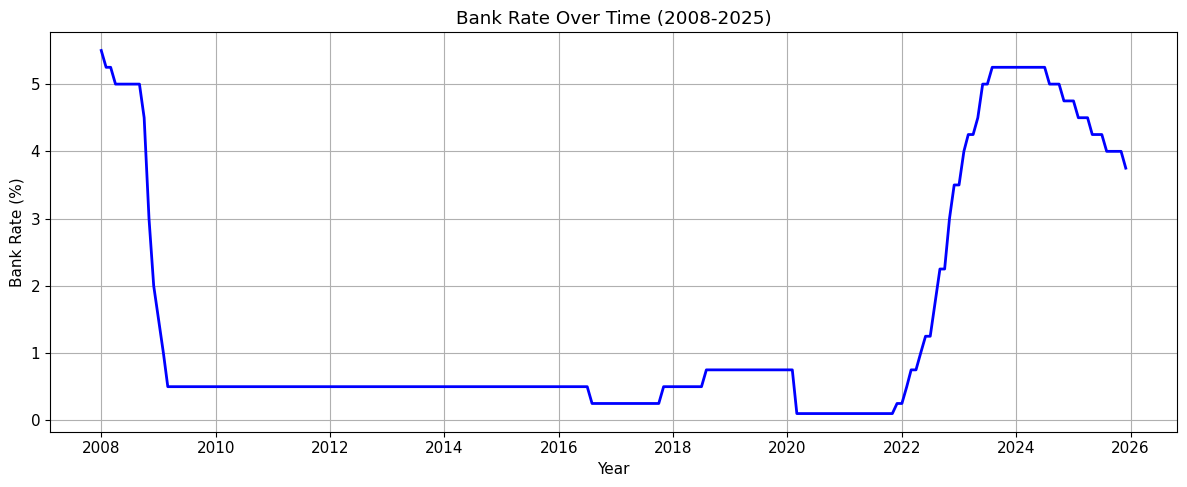

In [51]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Bank_Rate"], color="blue", linewidth=2)
plt.title("Bank Rate Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Bank Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**CPI**

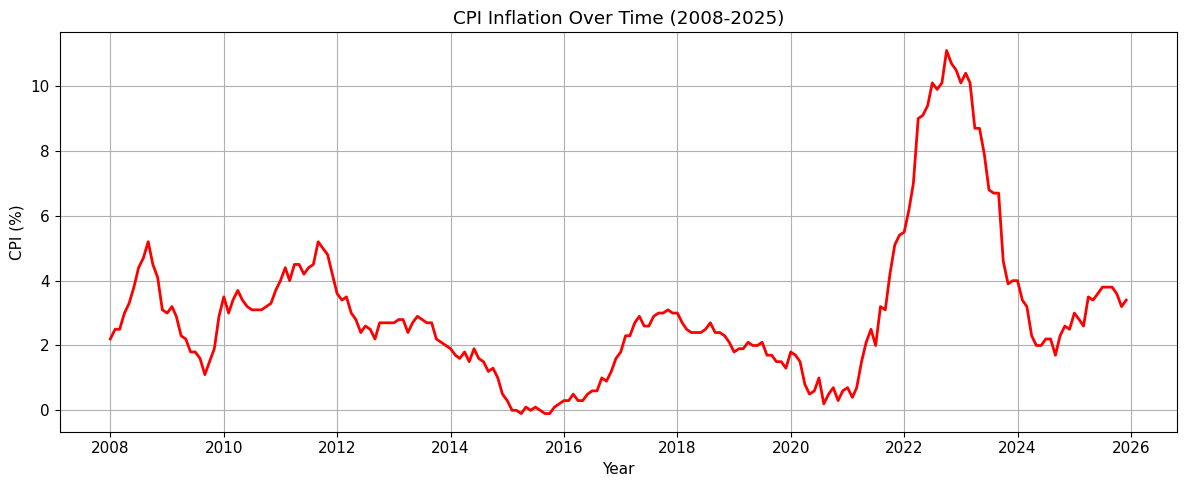

In [52]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["CPI"], color="red", linewidth=2)
plt.title("CPI Inflation Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("CPI (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**GDP Growth**


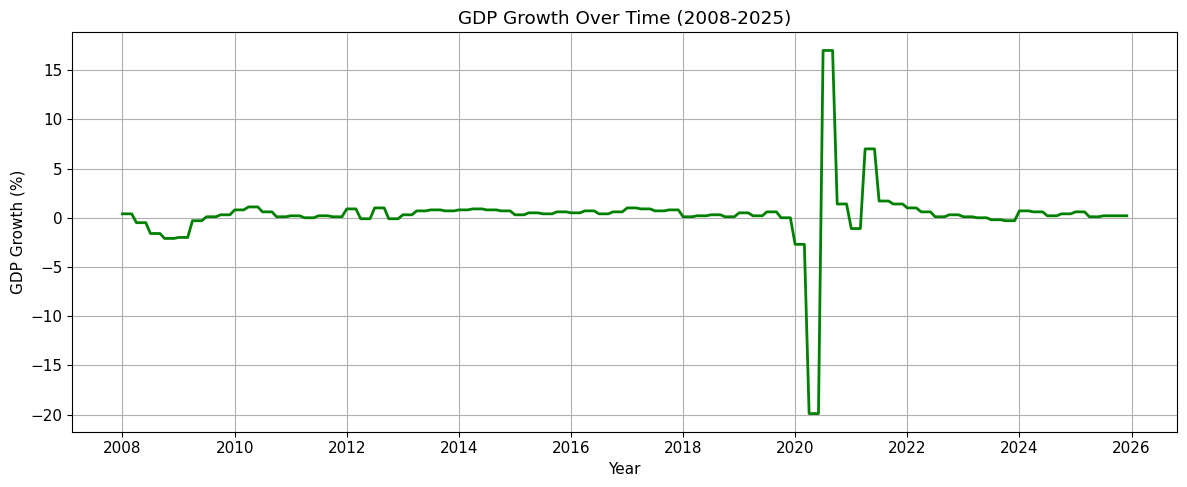

In [53]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["GDP_Growth"], color="green", linewidth=2)
plt.title("GDP Growth Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Unemployment Rate**

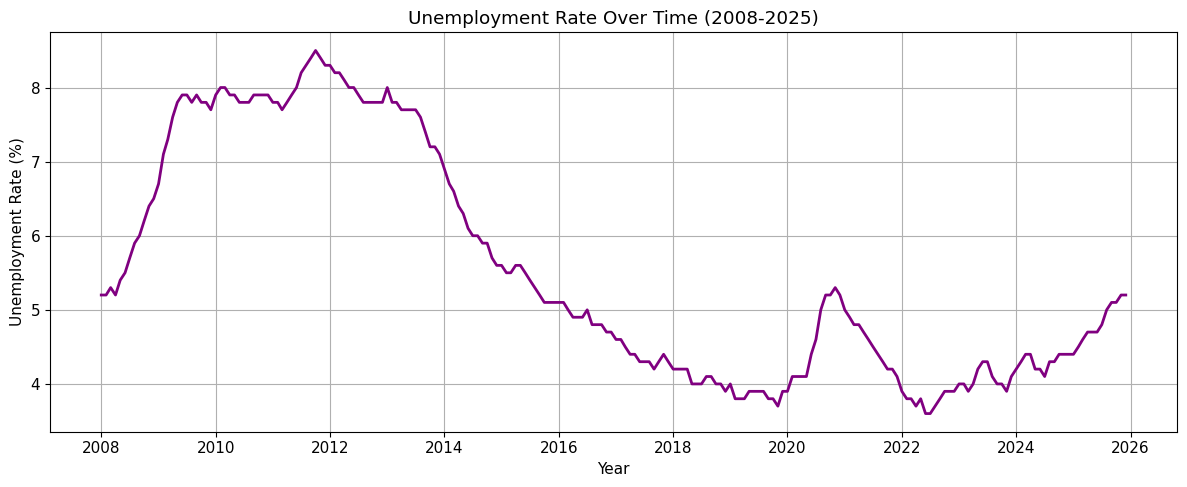

In [54]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Unemployment_Rate"], color="purple", linewidth=2)
plt.title("Unemployment Rate Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**House Price Index**

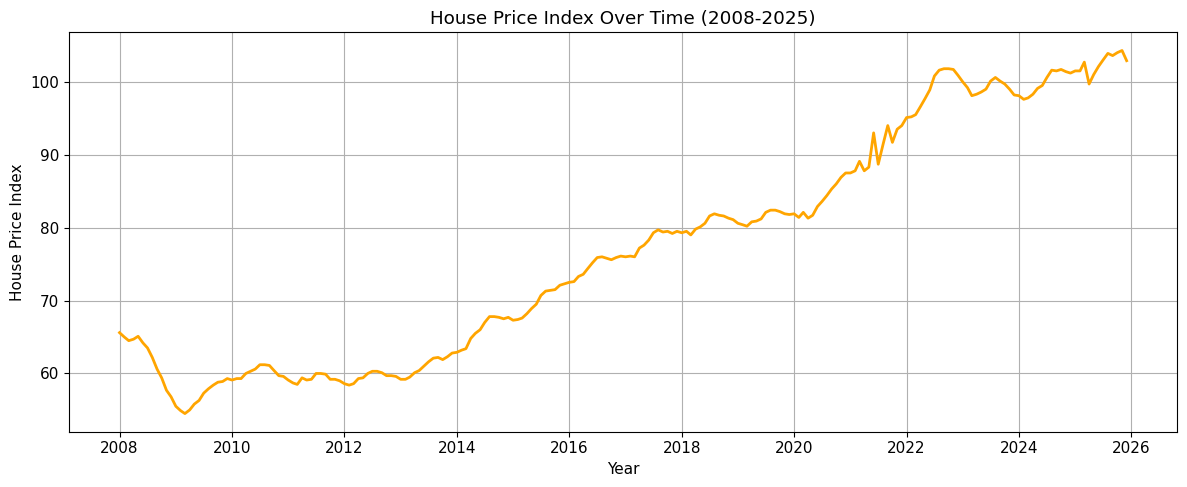

In [55]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["House_Price_Index"], color="orange", linewidth=2)
plt.title("House Price Index Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("House Price Index")
plt.grid(True)
plt.tight_layout()
plt.show()

**Current Accounts**

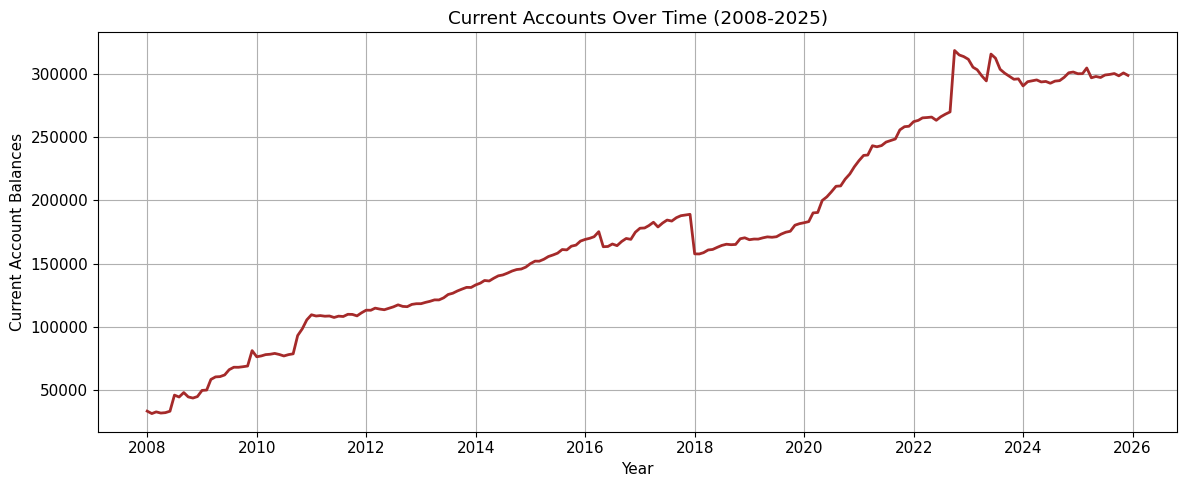

In [56]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Current_Accounts"], color="brown", linewidth=2)
plt.title("Current Accounts Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Current Account Balances")
plt.grid(True)
plt.tight_layout()
plt.show()

**Savings Account**

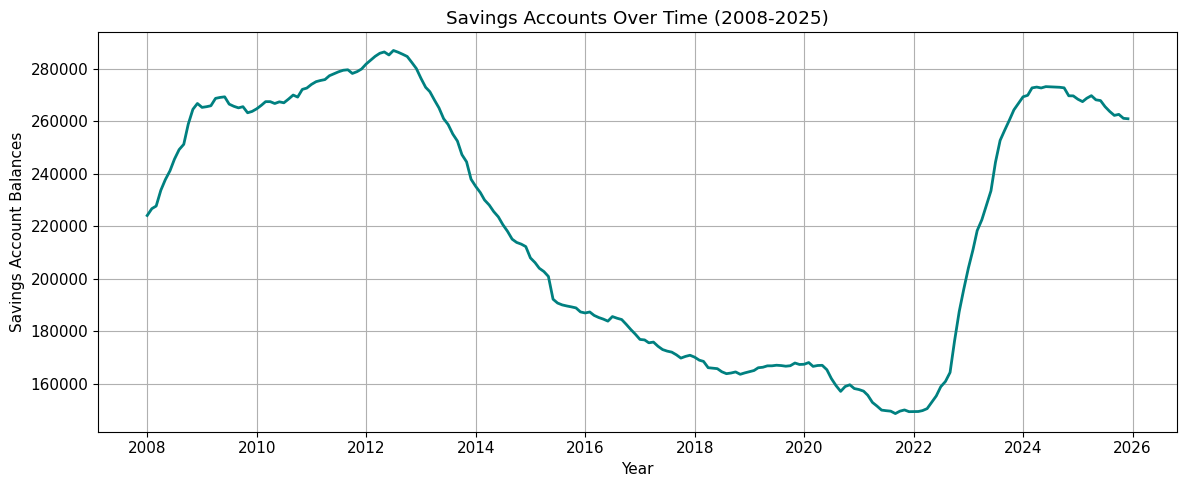

In [57]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Savings_Accounts"], color="teal", linewidth=2)
plt.title("Savings Accounts Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Savings Account Balances")
plt.grid(True)
plt.tight_layout()
plt.show()

**Mortgage Approvals**

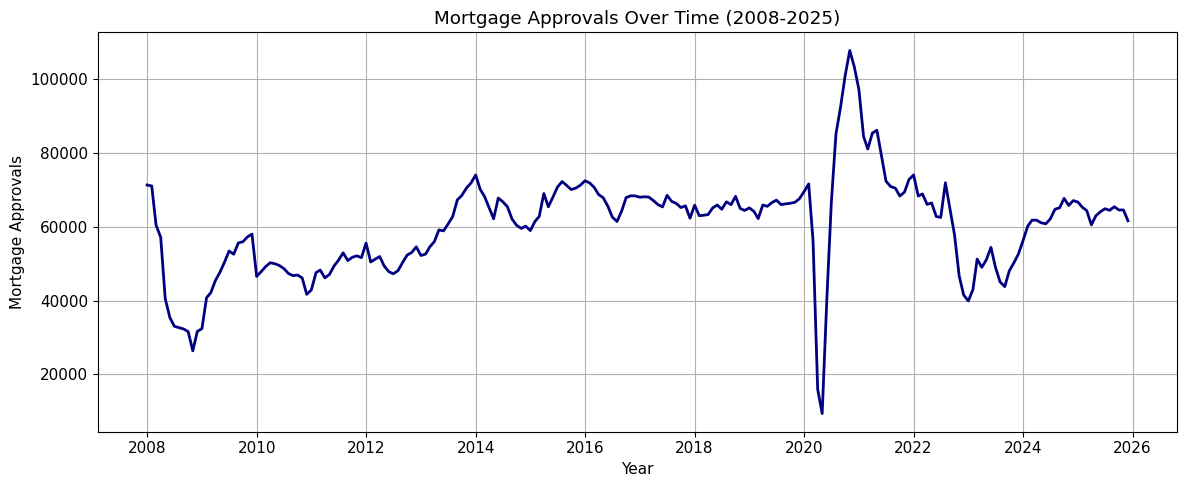

In [58]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Mortgage_Approvals"], color="navy", linewidth=2)
plt.title("Mortgage Approvals Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Mortgage Approvals")
plt.grid(True)
plt.tight_layout()
plt.show()

**Consumer Credit**

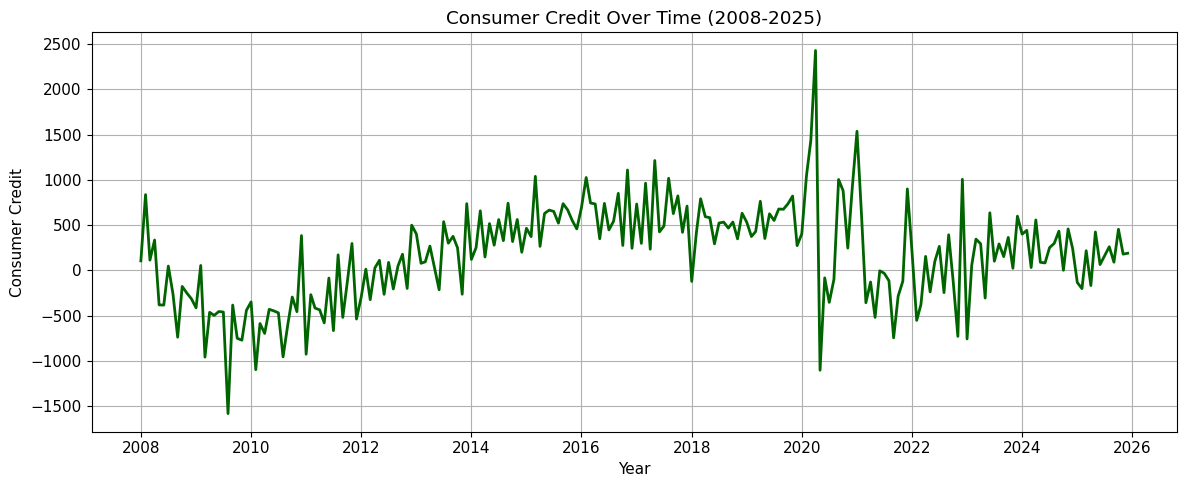

In [59]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Consumer_Credit"], color="darkgreen", linewidth=2)
plt.title("Consumer Credit Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Consumer Credit")
plt.grid(True)
plt.tight_layout()
plt.show()

**Credit Card Lending**

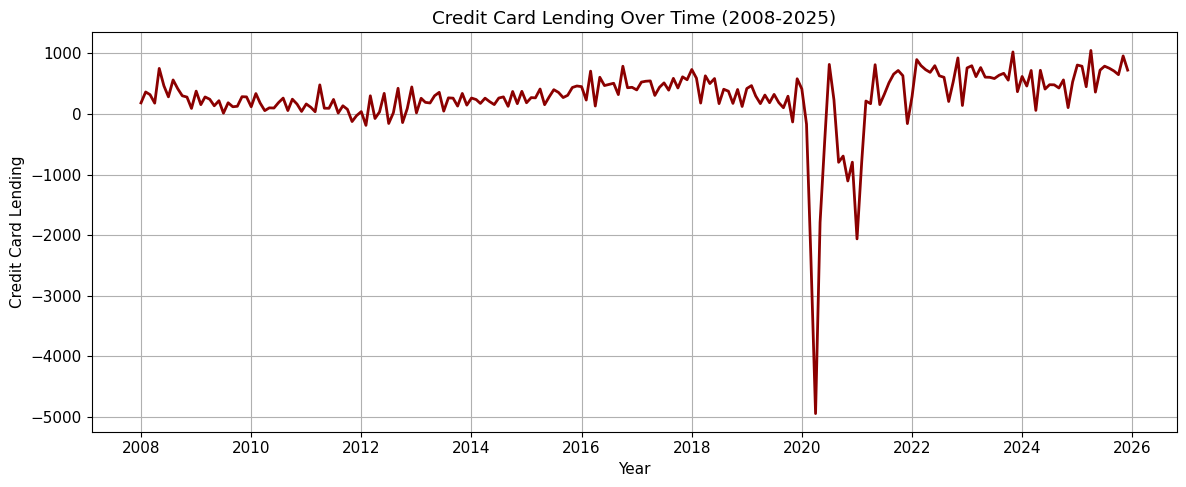

In [60]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Credit_Card_Lending"], color="darkred", linewidth=2)
plt.title("Credit Card Lending Over Time (2008-2025)")
plt.xlabel("Year")
plt.ylabel("Credit Card Lending")
plt.grid(True)
plt.tight_layout()
plt.show()

**Rolling Mean and Rolling Standard Deviation of Bank Rate**

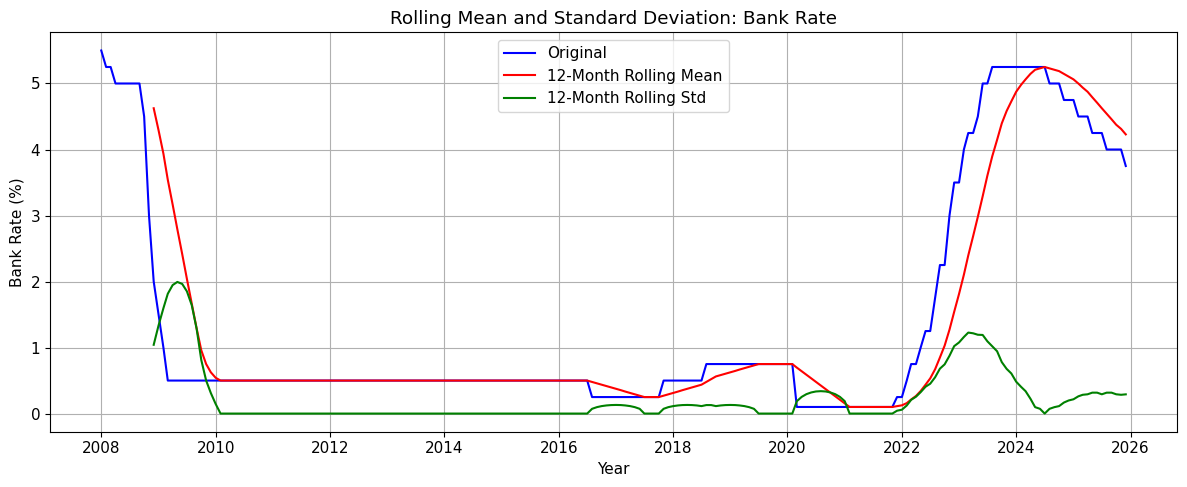

In [61]:
rolling_mean = df["Bank_Rate"].rolling(window=12).mean()
rolling_std = df["Bank_Rate"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Bank_Rate"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Bank Rate")
plt.xlabel("Year")
plt.ylabel("Bank Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**CPI**

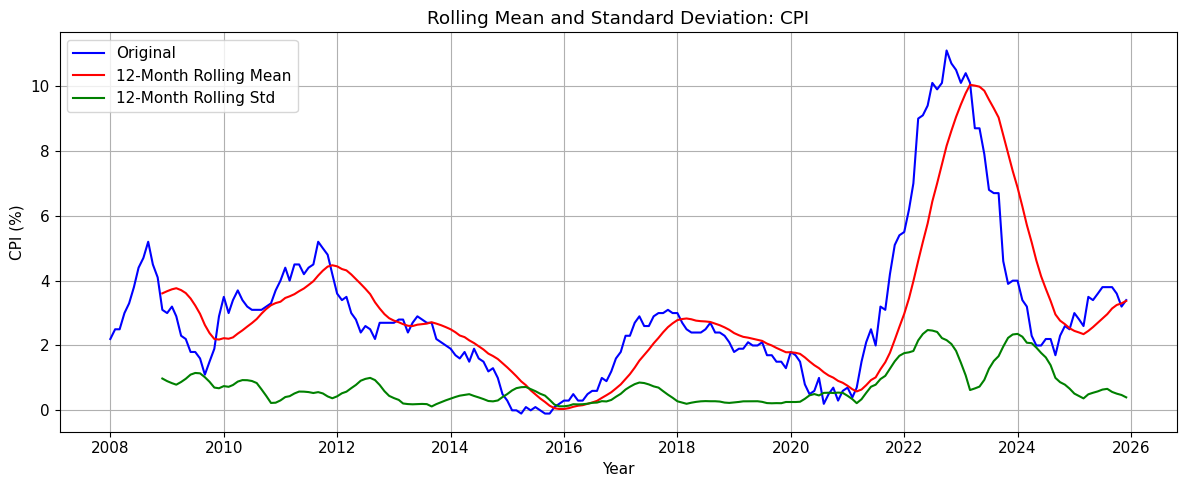

In [62]:
rolling_mean = df["CPI"].rolling(window=12).mean()
rolling_std = df["CPI"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["CPI"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: CPI")
plt.xlabel("Year")
plt.ylabel("CPI (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**GDP Growth**

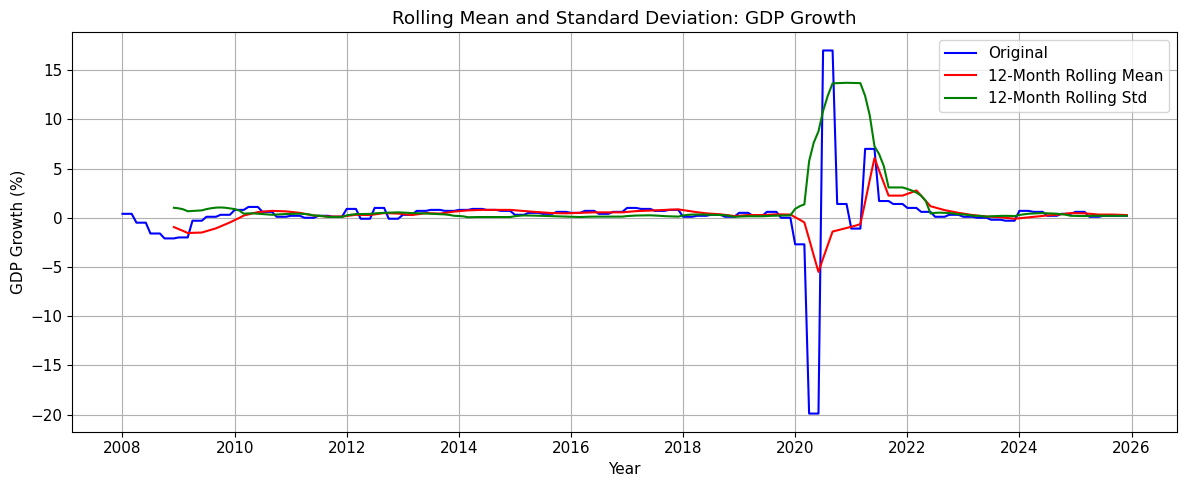

In [63]:
rolling_mean = df["GDP_Growth"].rolling(window=12).mean()
rolling_std = df["GDP_Growth"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["GDP_Growth"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: GDP Growth")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Unemployment Rate**

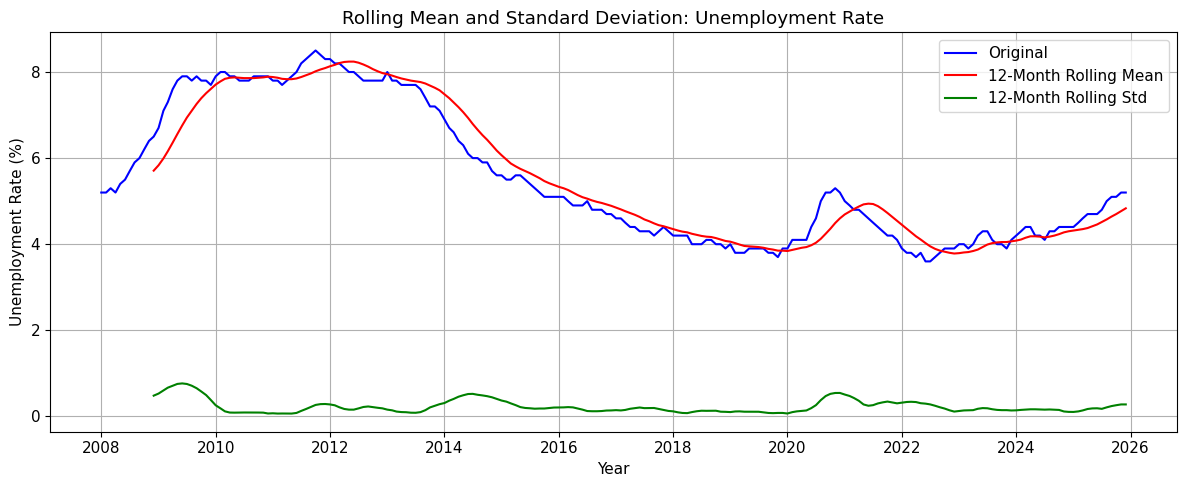

In [64]:
rolling_mean = df["Unemployment_Rate"].rolling(window=12).mean()
rolling_std = df["Unemployment_Rate"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Unemployment_Rate"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**House Price Index**

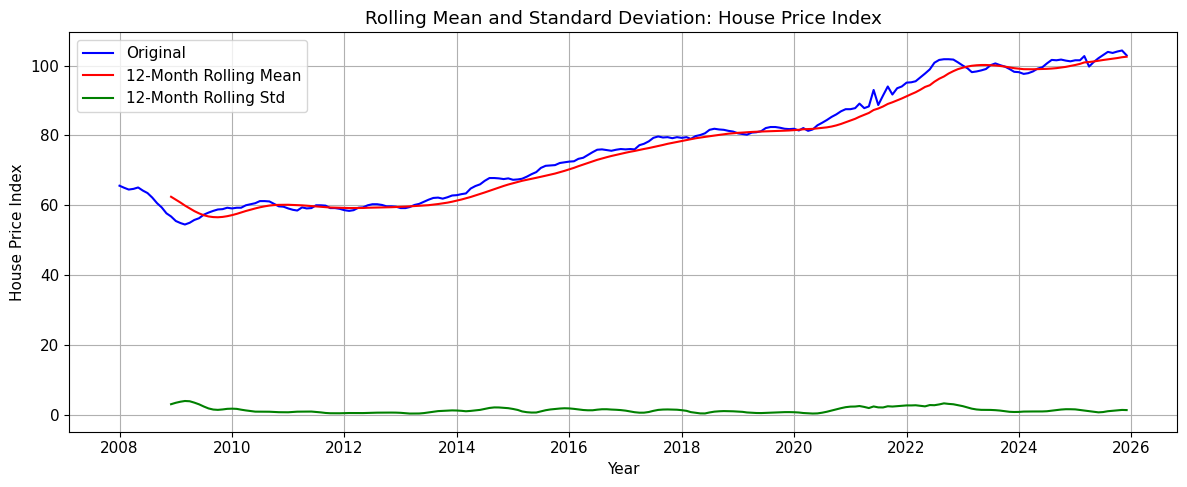

In [65]:
rolling_mean = df["House_Price_Index"].rolling(window=12).mean()
rolling_std = df["House_Price_Index"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["House_Price_Index"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: House Price Index")
plt.xlabel("Year")
plt.ylabel("House Price Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Current_Accounts**

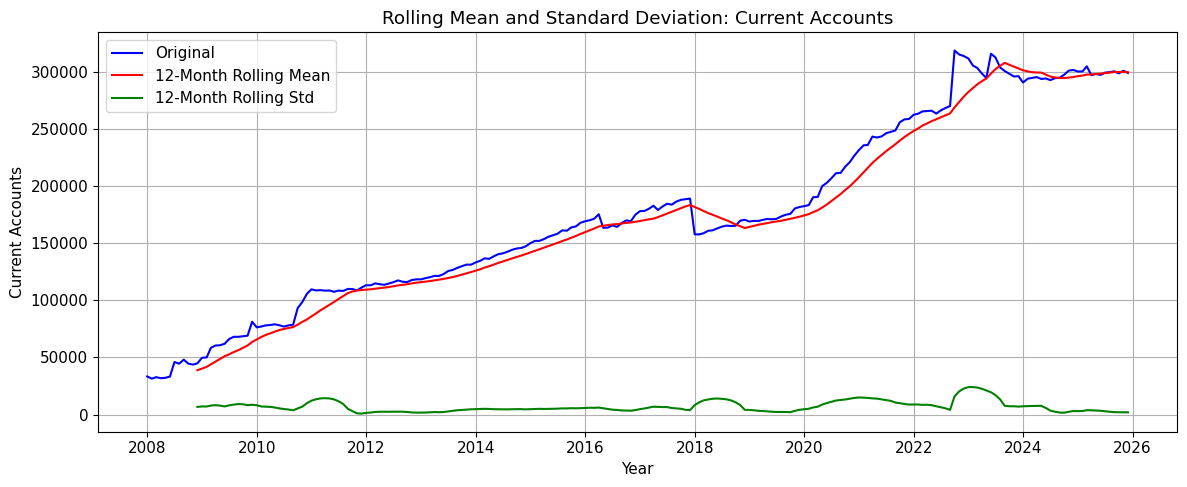

In [66]:
rolling_mean = df["Current_Accounts"].rolling(window=12).mean()
rolling_std = df["Current_Accounts"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Current_Accounts"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Current Accounts")
plt.xlabel("Year")
plt.ylabel("Current Accounts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Savings_Accounts**

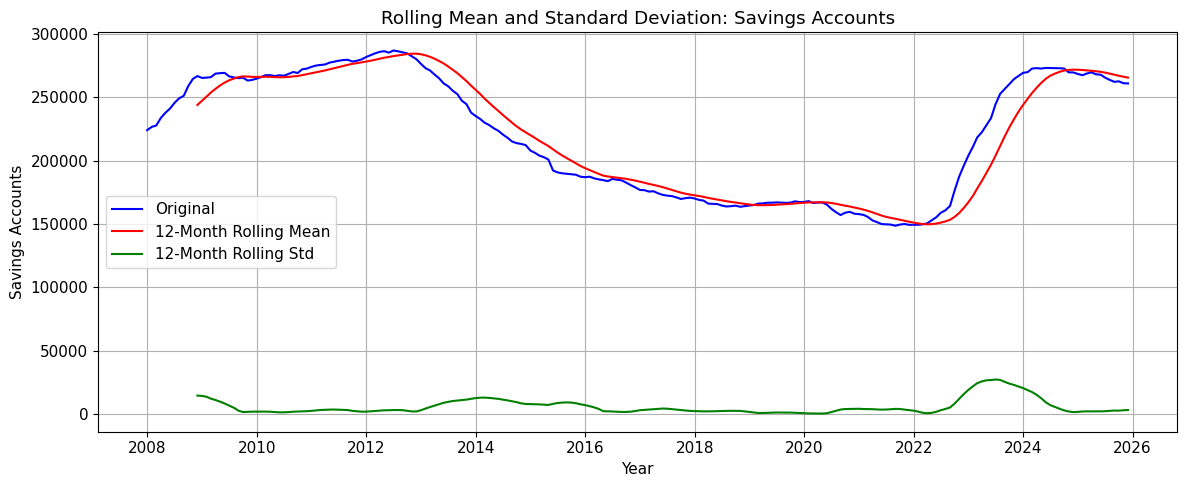

In [67]:
rolling_mean = df["Savings_Accounts"].rolling(window=12).mean()
rolling_std = df["Savings_Accounts"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Savings_Accounts"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Savings Accounts")
plt.xlabel("Year")
plt.ylabel("Savings Accounts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Mortgage_Approvals**


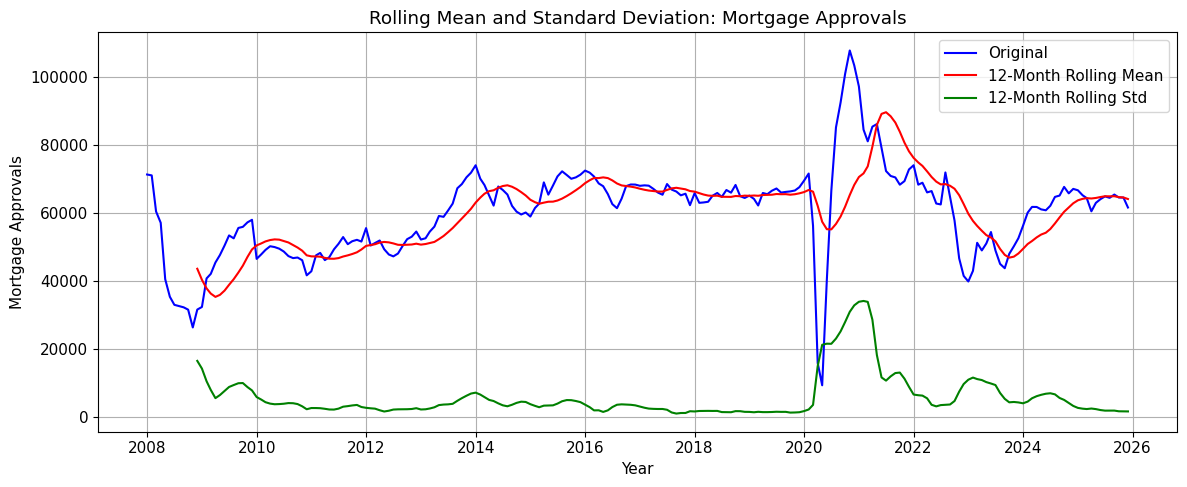

In [68]:
rolling_mean = df["Mortgage_Approvals"].rolling(window=12).mean()
rolling_std = df["Mortgage_Approvals"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Mortgage_Approvals"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Mortgage Approvals")
plt.xlabel("Year")
plt.ylabel("Mortgage Approvals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Consumer_Credit**

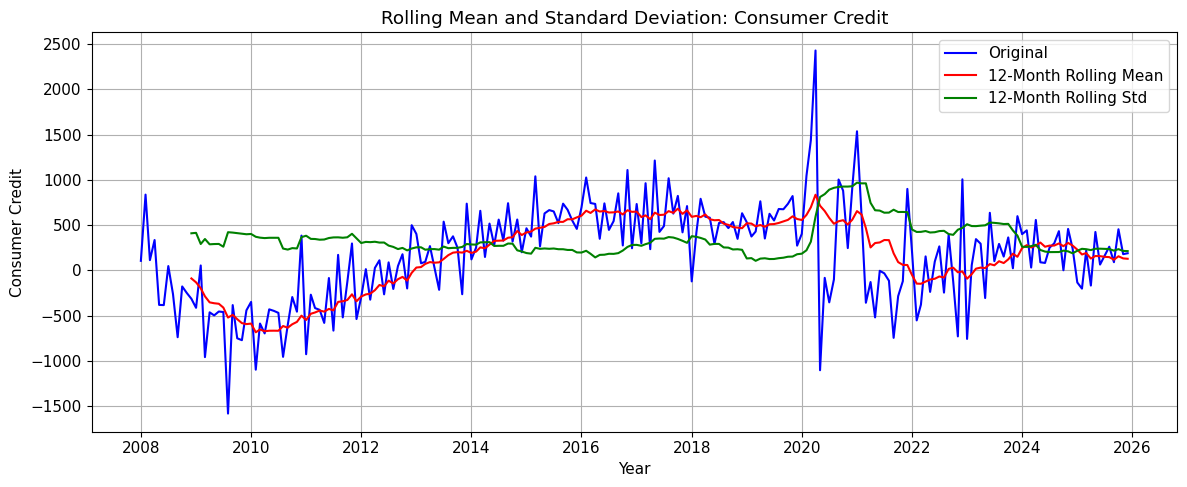

In [69]:
rolling_mean = df["Consumer_Credit"].rolling(window=12).mean()
rolling_std = df["Consumer_Credit"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Consumer_Credit"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Consumer Credit")
plt.xlabel("Year")
plt.ylabel("Consumer Credit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Credit_Card_Lending**

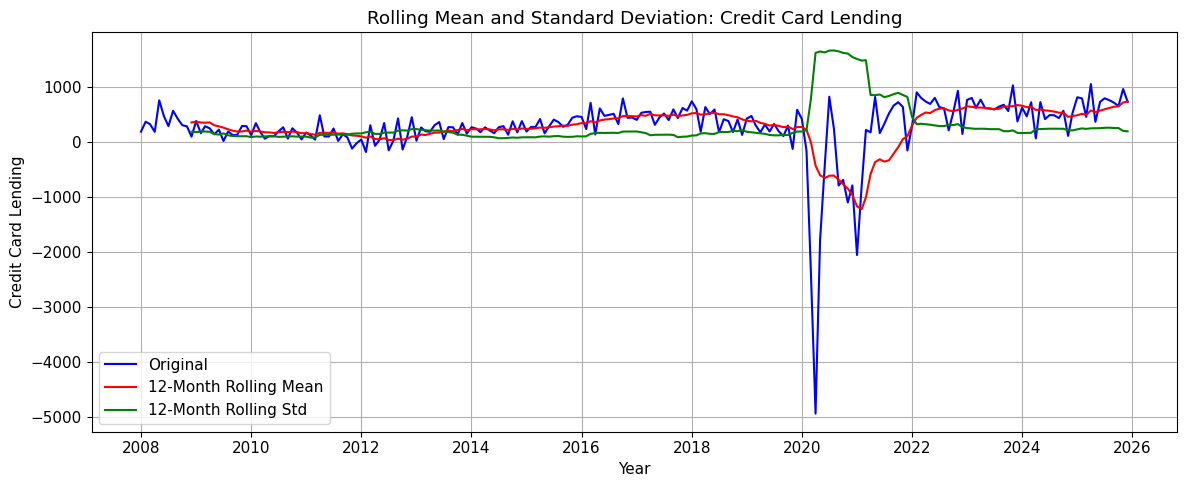

In [70]:
rolling_mean = df["Credit_Card_Lending"].rolling(window=12).mean()
rolling_std = df["Credit_Card_Lending"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Credit_Card_Lending"], label="Original", color="blue")
plt.plot(rolling_mean, label="12-Month Rolling Mean", color="red")
plt.plot(rolling_std, label="12-Month Rolling Std", color="green")
plt.title("Rolling Mean and Standard Deviation: Credit Card Lending")
plt.xlabel("Year")
plt.ylabel("Credit Card Lending")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Helper Functions**

In [71]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import kpss

def kpss_test(series, name):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)

        statistic, p_value, lags, critical_values = kpss(
            series.dropna(),
            regression="c",
            nlags="auto"
        )

    print("="*60)
    print(f"KPSS Test: {name}")
    print("="*60)
    print(f"KPSS Statistic: {statistic:.4f}")
    print(f"p-value       : {p_value:.4f}")
    print(f"Lags Used     : {lags}")

    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value < 0.05:
        print("Result: Non-Stationary (Reject H0)")
    else:
        print("Result: Stationary (Fail to Reject H0)")
    print()

**Bank Rate**

In [72]:
adf_test(df["Bank_Rate"], "Bank Rate")
kpss_test(df["Bank_Rate"], "Bank Rate")

ADF Test: Bank Rate
ADF Statistic : -2.3051
p-value       : 0.1703
Lags Used     : 5
Observations  : 210
Critical Values:
  1%: -3.4619
  5%: -2.8754
  10%: -2.5742
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Bank Rate
KPSS Statistic: 0.6312
p-value       : 0.0198
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**CPI**

In [73]:
adf_test(df["CPI"], "CPI")
kpss_test(df["CPI"], "CPI")

ADF Test: CPI
ADF Statistic : -2.5817
p-value       : 0.0968
Lags Used     : 12
Observations  : 203
Critical Values:
  1%: -3.4630
  5%: -2.8759
  10%: -2.5744
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: CPI
KPSS Statistic: 0.3233
p-value       : 0.1000
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Stationary (Fail to Reject H0)



**GDP Growth**

In [74]:
adf_test(df["GDP_Growth"], "GDP Growth")
kpss_test(df["GDP_Growth"], "GDP Growth")

ADF Test: GDP Growth
ADF Statistic : -4.2966
p-value       : 0.0005
Lags Used     : 9
Observations  : 206
Critical Values:
  1%: -3.4625
  5%: -2.8757
  10%: -2.5743
Result: Stationary (Reject H0)

KPSS Test: GDP Growth
KPSS Statistic: 0.0727
p-value       : 0.1000
Lags Used     : 1
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Stationary (Fail to Reject H0)



**Unemployment Rate**


In [75]:
adf_test(df["Unemployment_Rate"], "Unemployment Rate")
kpss_test(df["Unemployment_Rate"], "Unemployment Rate")

ADF Test: Unemployment Rate
ADF Statistic : -1.1228
p-value       : 0.7059
Lags Used     : 2
Observations  : 213
Critical Values:
  1%: -3.4614
  5%: -2.8752
  10%: -2.5741
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Unemployment Rate
KPSS Statistic: 1.6162
p-value       : 0.0100
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**House Price Index**

In [76]:
adf_test(df["House_Price_Index"], "House Price Index")
kpss_test(df["House_Price_Index"], "House Price Index")

ADF Test: House Price Index
ADF Statistic : 0.0027
p-value       : 0.9588
Lags Used     : 15
Observations  : 200
Critical Values:
  1%: -3.4635
  5%: -2.8761
  10%: -2.5745
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: House Price Index
KPSS Statistic: 2.1683
p-value       : 0.0100
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**Current Accounts**

In [77]:
adf_test(df["Current_Accounts"], "Current Accounts")
kpss_test(df["Current_Accounts"], "Current Accounts")

ADF Test: Current Accounts
ADF Statistic : -0.8068
p-value       : 0.8171
Lags Used     : 8
Observations  : 207
Critical Values:
  1%: -3.4623
  5%: -2.8756
  10%: -2.5743
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Current Accounts
KPSS Statistic: 2.1332
p-value       : 0.0100
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**Savings Accounts**

In [78]:
adf_test(df["Savings_Accounts"], "Savings Accounts")
kpss_test(df["Savings_Accounts"], "Savings Accounts")

ADF Test: Savings Accounts
ADF Statistic : -2.0667
p-value       : 0.2581
Lags Used     : 4
Observations  : 211
Critical Values:
  1%: -3.4617
  5%: -2.8753
  10%: -2.5741
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Savings Accounts
KPSS Statistic: 0.7592
p-value       : 0.0100
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**Mortgage Approvals**

In [79]:
adf_test(df["Mortgage_Approvals"], "Mortgage Approvals")
kpss_test(df["Mortgage_Approvals"], "Mortgage Approvals")

ADF Test: Mortgage Approvals
ADF Statistic : -3.9996
p-value       : 0.0014
Lags Used     : 2
Observations  : 213
Critical Values:
  1%: -3.4614
  5%: -2.8752
  10%: -2.5741
Result: Stationary (Reject H0)

KPSS Test: Mortgage Approvals
KPSS Statistic: 0.7362
p-value       : 0.0103
Lags Used     : 9
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**Consumer Credit**

In [80]:
adf_test(df["Consumer_Credit"], "Consumer Credit")
kpss_test(df["Consumer_Credit"], "Consumer Credit")

ADF Test: Consumer Credit
ADF Statistic : -1.3067
p-value       : 0.6261
Lags Used     : 10
Observations  : 205
Critical Values:
  1%: -3.4627
  5%: -2.8757
  10%: -2.5743
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Consumer Credit
KPSS Statistic: 0.8436
p-value       : 0.0100
Lags Used     : 8
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)



**Credit Card Lending**

In [81]:
adf_test(df["Credit_Card_Lending"], "Credit Card Lending")
kpss_test(df["Credit_Card_Lending"], "Credit Card Lending")

ADF Test: Credit Card Lending
ADF Statistic : -2.4019
p-value       : 0.1412
Lags Used     : 9
Observations  : 206
Critical Values:
  1%: -3.4625
  5%: -2.8757
  10%: -2.5743
Result: Non-Stationary (Fail to Reject H0)

KPSS Test: Credit Card Lending
KPSS Statistic: 0.2223
p-value       : 0.1000
Lags Used     : 7
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Stationary (Fail to Reject H0)



**First-Order Differencing**

In [82]:
non_stationary = [
    "Bank_Rate",
    "CPI",
    "Unemployment_Rate",
    "House_Price_Index",
    "Current_Accounts",
    "Savings_Accounts",
    "Consumer_Credit"
]

df_diff = pd.DataFrame(index=df.index)

for col in non_stationary:
    df_diff[col] = df[col].diff()

df_diff = df_diff.dropna()

df_diff.head()

,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,Current_Accounts,Savings_Accounts,Consumer_Credit
Date,,,,,,,
2008-02-01,-0.25,0.3,0.0,-0.6,-1925.0,2613.0,732.0
2008-03-01,0.00,0.0,0.1,-0.5,1331.0,997.0,-724.0
2008-04-01,-0.25,0.5,-0.1,0.2,-928.0,5997.0,222.0
2008-05-01,0.00,0.3,0.2,0.4,315.0,4054.0,-717.0
2008-06-01,0.00,0.5,0.1,-0.9,1138.0,3364.0,-2.0


**Bank Rate**

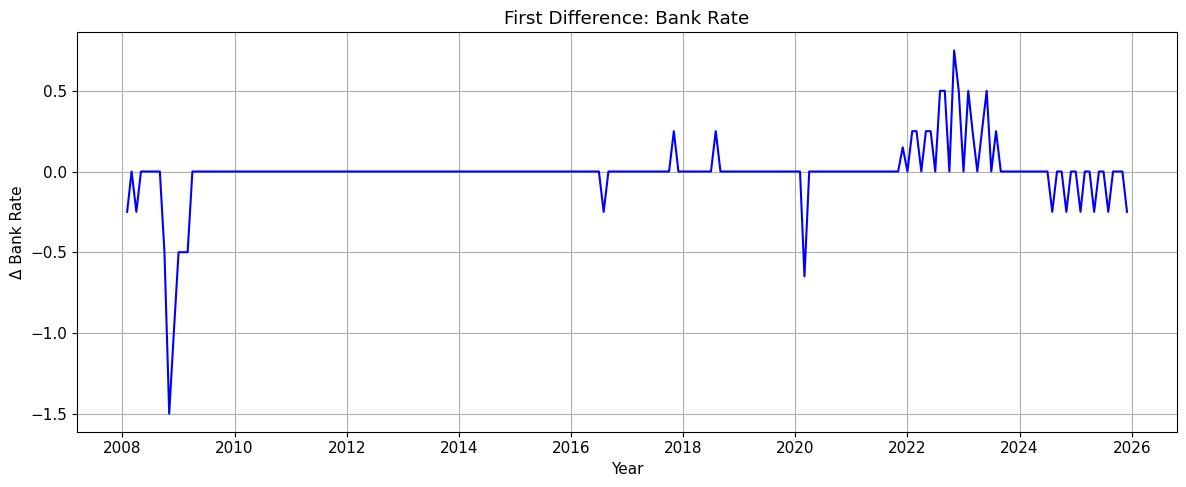

In [83]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["Bank_Rate"], color="blue")
plt.title("First Difference: Bank Rate")
plt.xlabel("Year")
plt.ylabel("Δ Bank Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

**CPI**

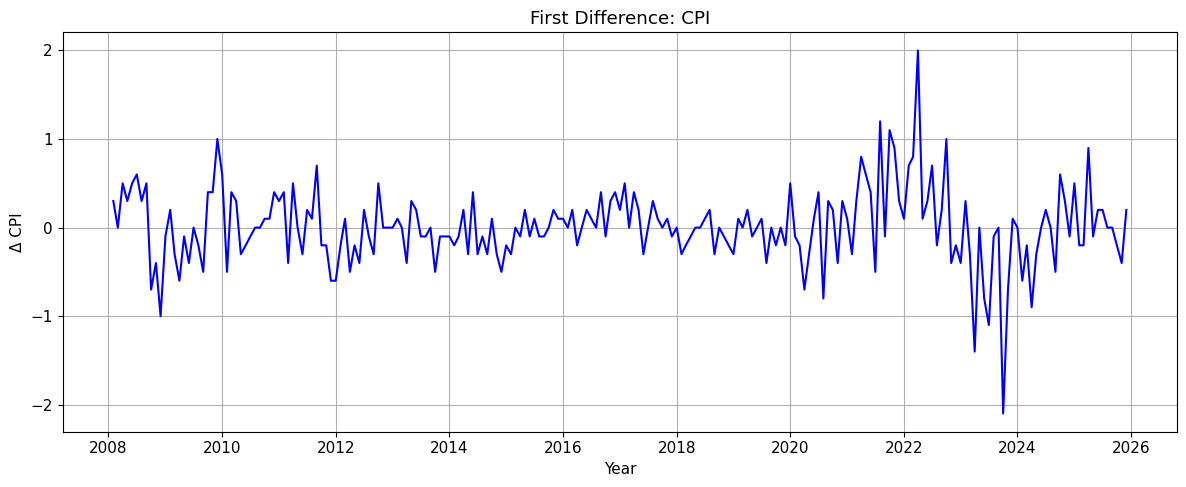

In [84]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["CPI"], color="blue")
plt.title("First Difference: CPI")
plt.xlabel("Year")
plt.ylabel("Δ CPI")
plt.grid(True)
plt.tight_layout()
plt.show()

**Unemployment Rate**

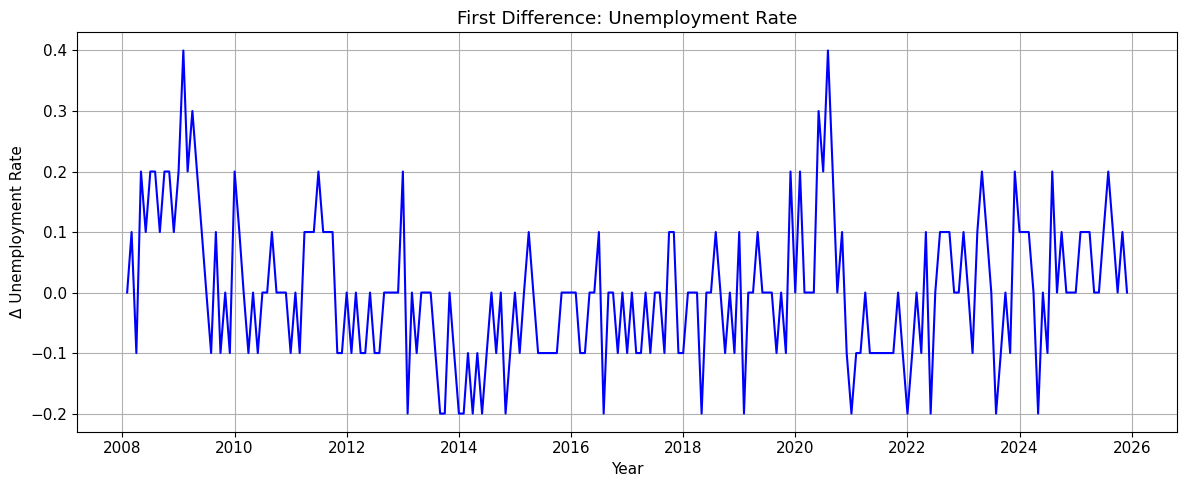

In [85]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["Unemployment_Rate"], color="blue")
plt.title("First Difference: Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Δ Unemployment Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

**House Price Index**

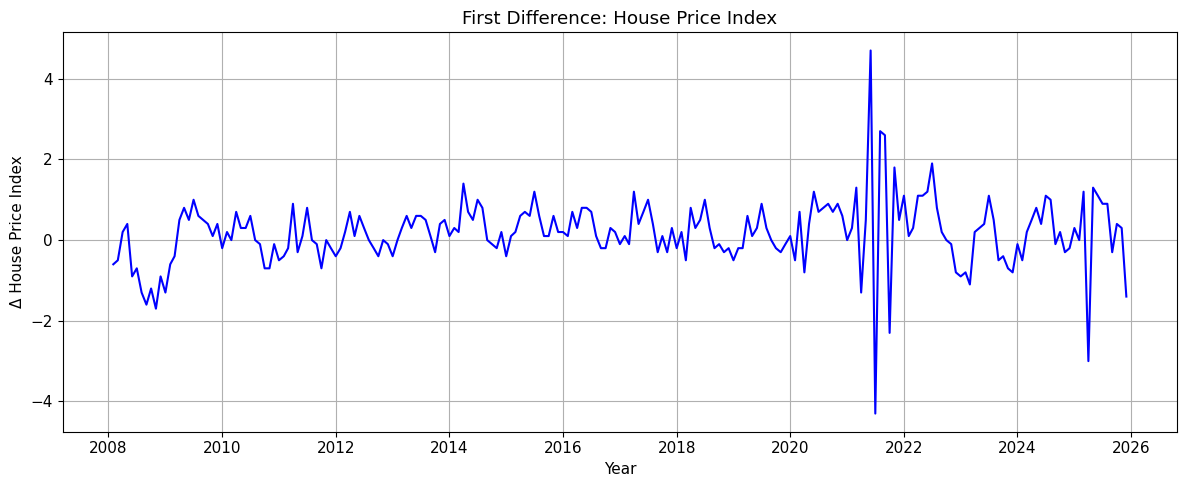

In [86]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["House_Price_Index"], color="blue")
plt.title("First Difference: House Price Index")
plt.xlabel("Year")
plt.ylabel("Δ House Price Index")
plt.grid(True)
plt.tight_layout()
plt.show()

**Current_Accounts**


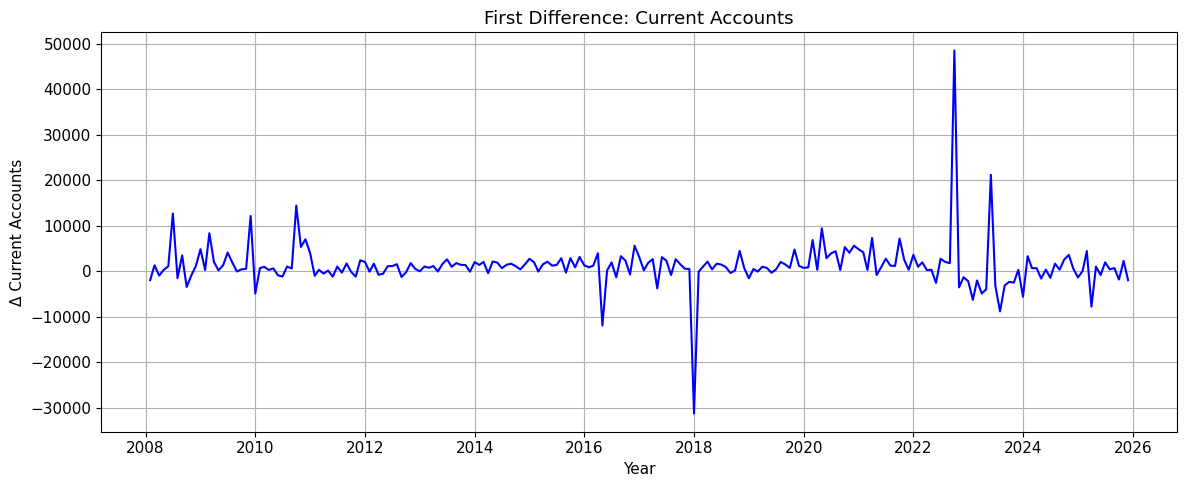

In [87]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["Current_Accounts"], color="blue")
plt.title("First Difference: Current Accounts")
plt.xlabel("Year")
plt.ylabel("Δ Current Accounts")
plt.grid(True)
plt.tight_layout()
plt.show()

**Savings Accounts**

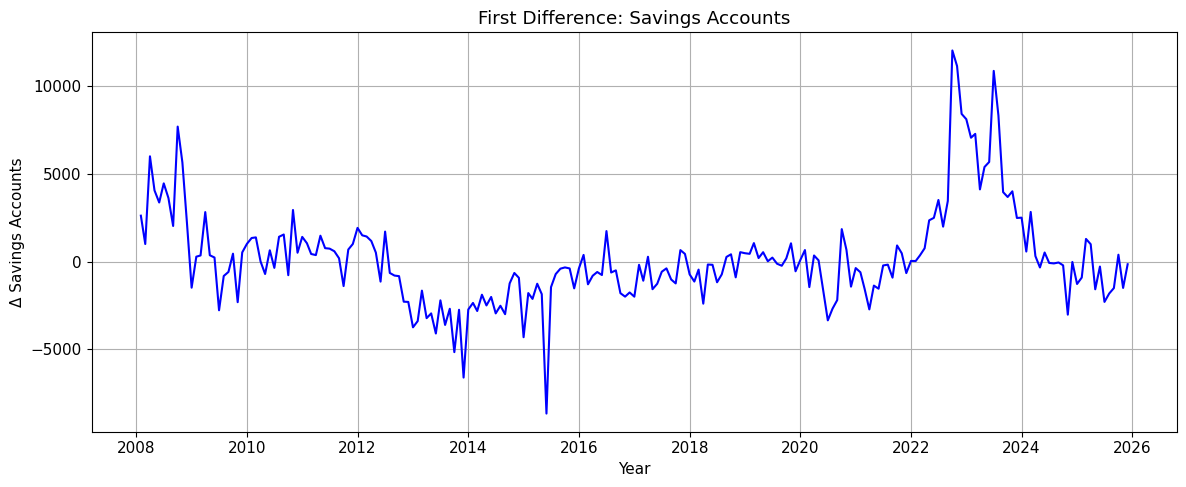

In [88]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["Savings_Accounts"], color="blue")
plt.title("First Difference: Savings Accounts")
plt.xlabel("Year")
plt.ylabel("Δ Savings Accounts")
plt.grid(True)
plt.tight_layout()
plt.show()

**Consumer Credit**

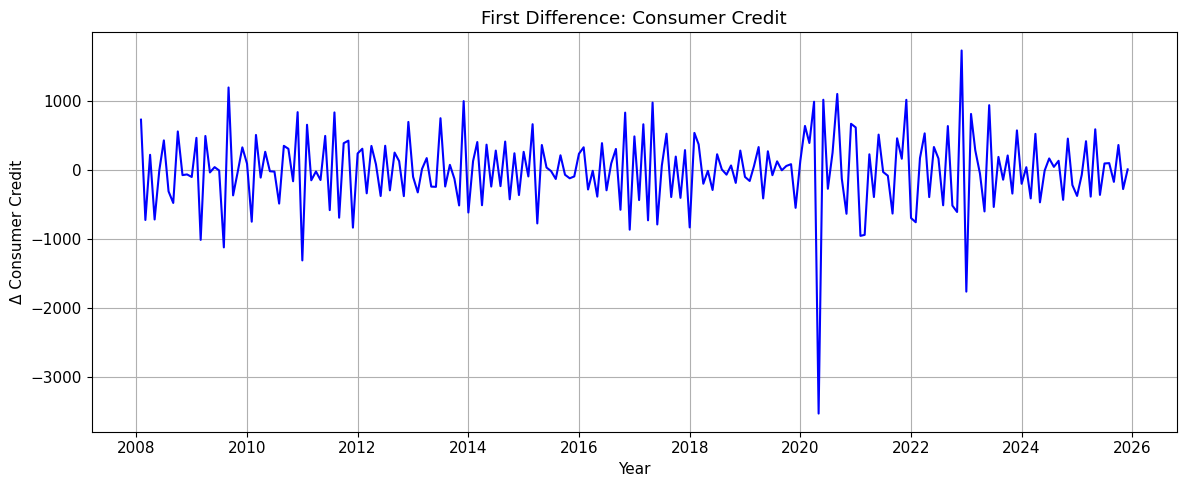

In [89]:
plt.figure(figsize=(12,5))
plt.plot(df_diff.index, df_diff["Consumer_Credit"], color="blue")
plt.title("First Difference: Consumer Credit")
plt.xlabel("Year")
plt.ylabel("Δ Consumer Credit")
plt.grid(True)
plt.tight_layout()
plt.show()

**Re-run ADF and KPSS on Differenced Series**

In [90]:
for col in non_stationary:
    print("\\n" + "="*70)
    print(f"DIFFERENCED SERIES: {col}")
    print("="*70)

    adf_test(df_diff[col], f"{col} (Differenced)")
    kpss_test(df_diff[col], f"{col} (Differenced)")

\n======================================================================
DIFFERENCED SERIES: Bank_Rate
ADF Test: Bank_Rate (Differenced)
ADF Statistic : -4.0507
p-value       : 0.0012
Lags Used     : 2
Observations  : 212
Critical Values:
  1%: -3.4616
  5%: -2.8753
  10%: -2.5741
Result: Stationary (Reject H0)

KPSS Test: Bank_Rate (Differenced)
KPSS Statistic: 0.4777
p-value       : 0.0467
Lags Used     : 8
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary (Reject H0)

\n======================================================================
DIFFERENCED SERIES: CPI
ADF Test: CPI (Differenced)
ADF Statistic : -4.6039
p-value       : 0.0001
Lags Used     : 11
Observations  : 203
Critical Values:
  1%: -3.4630
  5%: -2.8759
  10%: -2.5744
Result: Stationary (Reject H0)

KPSS Test: CPI (Differenced)
KPSS Statistic: 0.0514
p-value       : 0.1000
Lags Used     : 7
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Sta

**ACF and PACF**

**ACF Of Differenced Bank Rate**


<Figure size 1000x400 with 0 Axes>

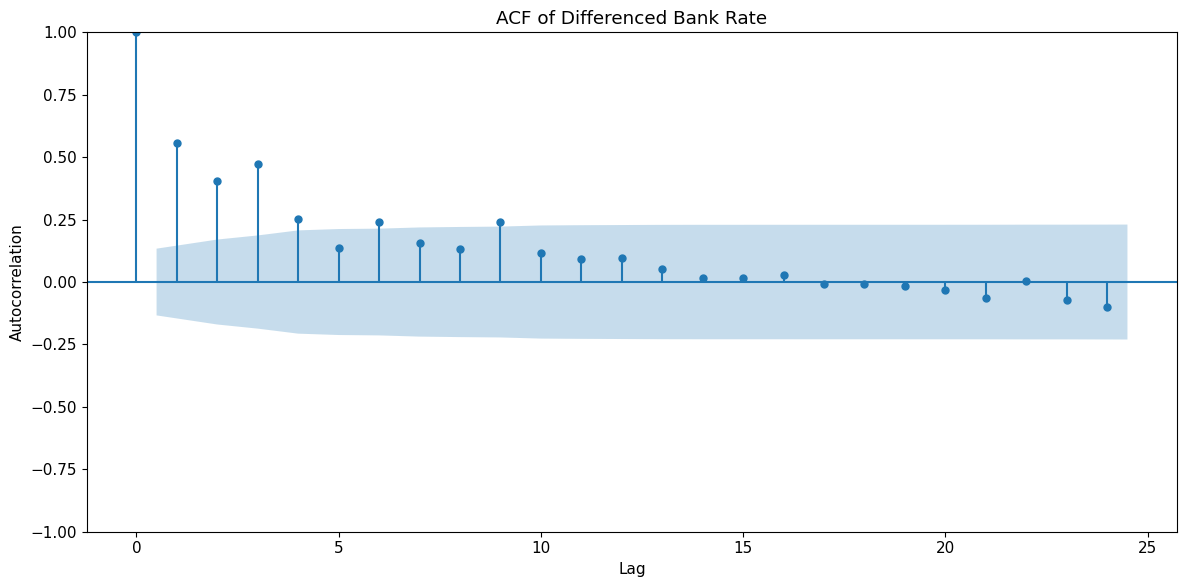

In [92]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(df_diff["Bank_Rate"], lags=24)
plt.title("ACF of Differenced Bank Rate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced Bank Rate**

<Figure size 1000x400 with 0 Axes>

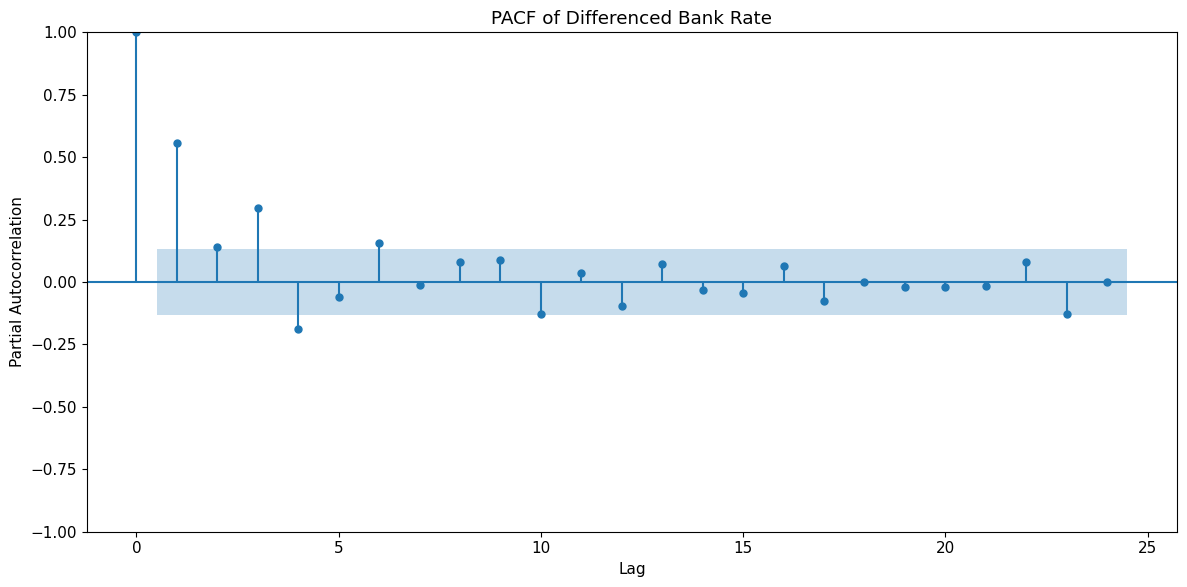

In [93]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_pacf(df_diff["Bank_Rate"], lags=24, method="ywm")
plt.title("PACF of Differenced Bank Rate")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced CPI**

<Figure size 1000x400 with 0 Axes>

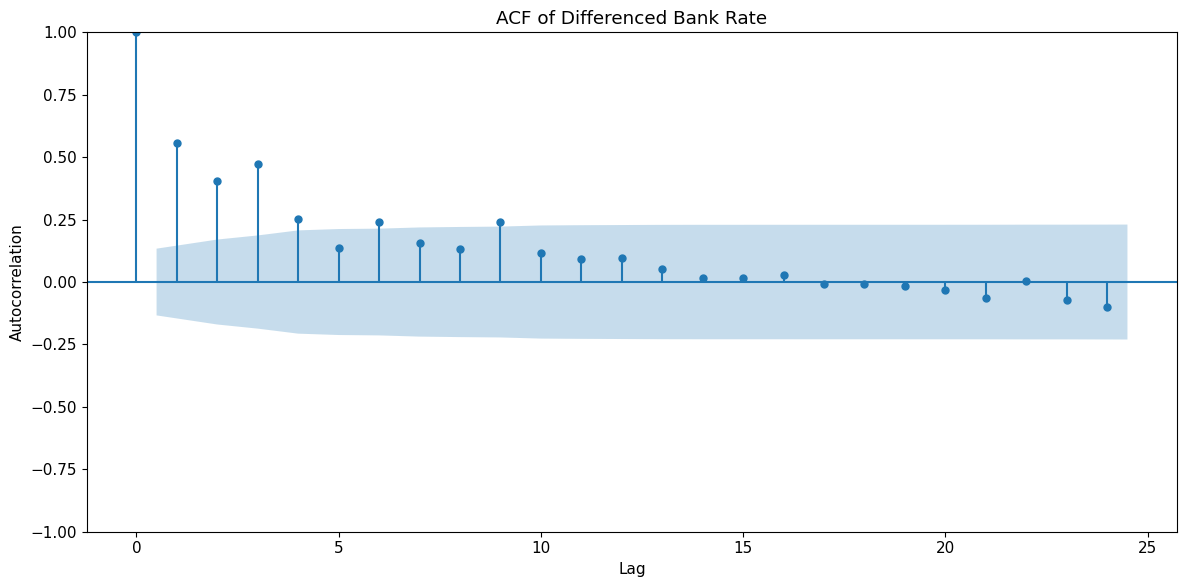

In [95]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["Bank_Rate"], lags=24)
plt.title("ACF of Differenced Bank Rate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()


**PACF of Differenced CPI**

<Figure size 1000x400 with 0 Axes>

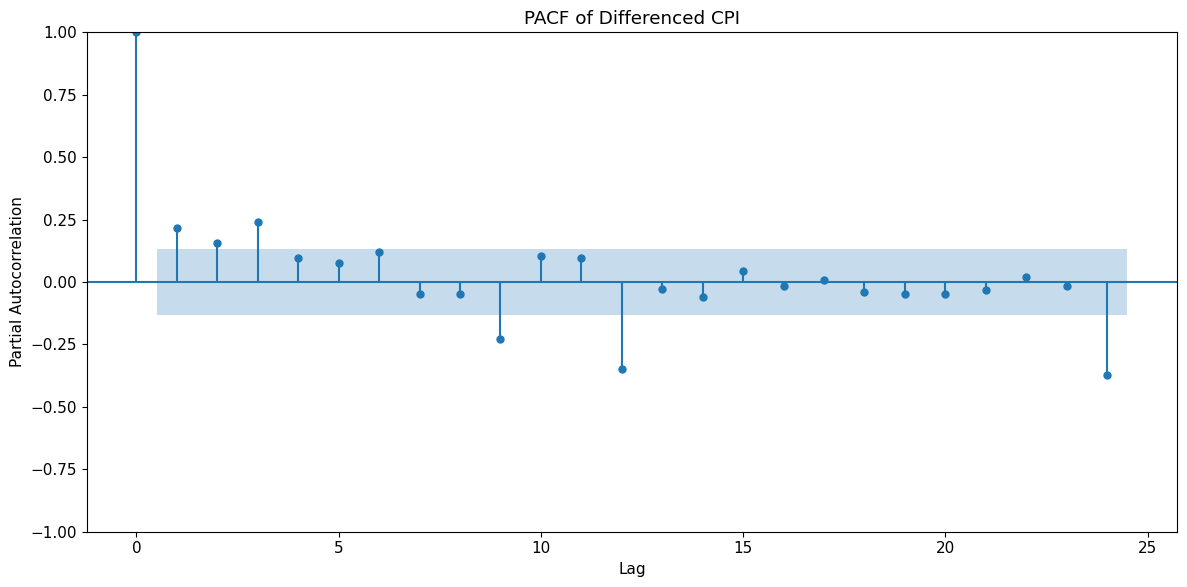

In [101]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["CPI"], lags=24, method="ywm")
plt.title("PACF of Differenced CPI")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced Unemployment Rate**

<Figure size 1000x400 with 0 Axes>

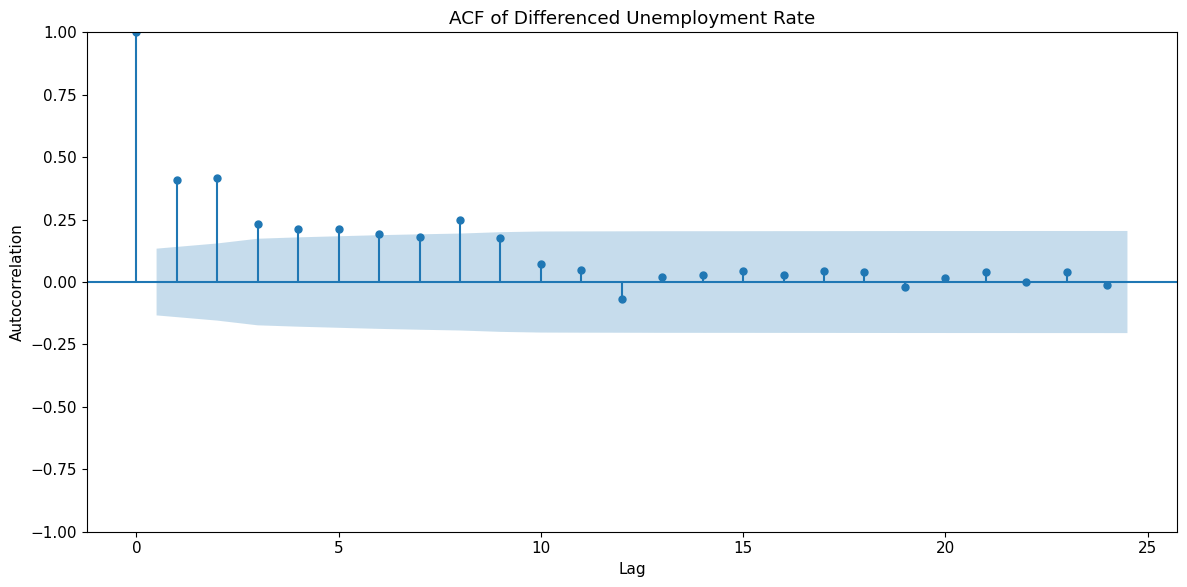

In [96]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["Unemployment_Rate"], lags=24)
plt.title("ACF of Differenced Unemployment Rate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced Unemployment Rate**

<Figure size 1000x400 with 0 Axes>

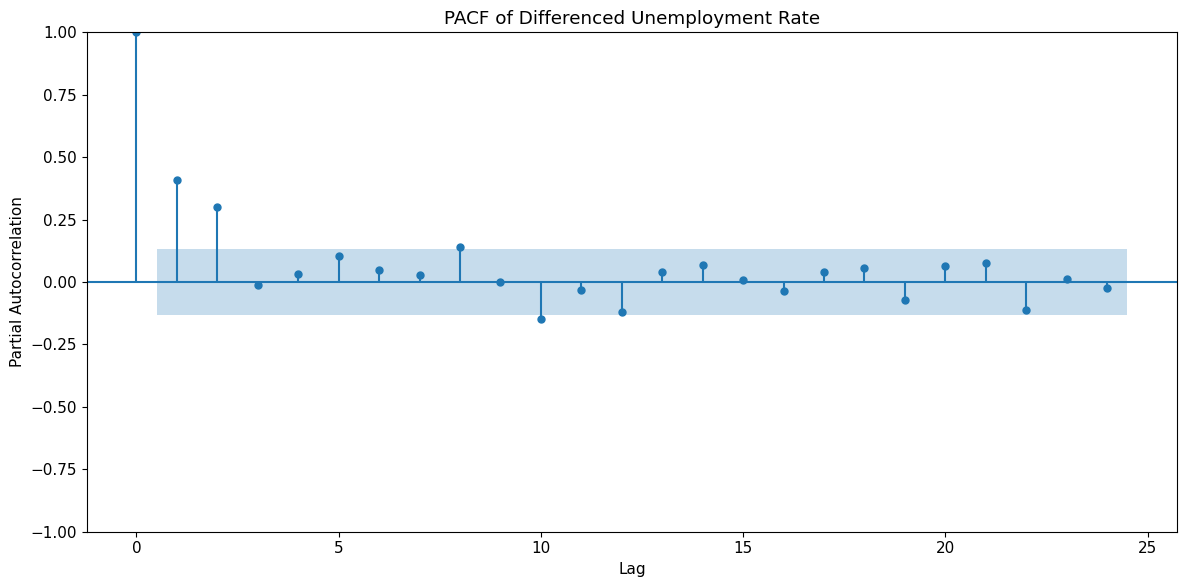

In [102]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["Unemployment_Rate"], lags=24, method="ywm")
plt.title("PACF of Differenced Unemployment Rate")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced House Price Index**

<Figure size 1000x400 with 0 Axes>

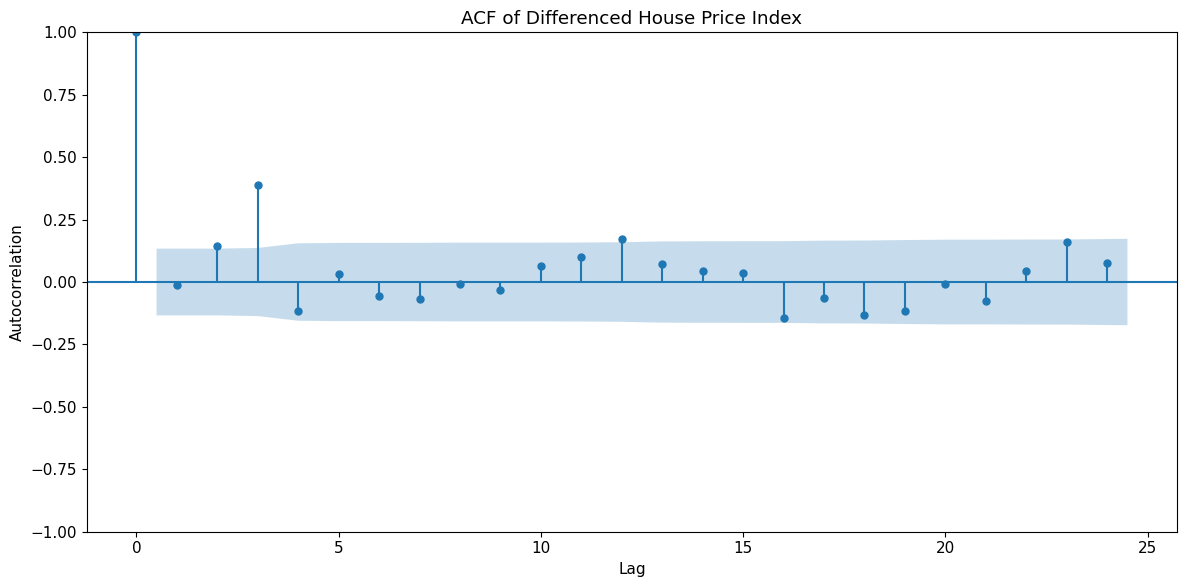

In [97]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["House_Price_Index"], lags=24)
plt.title("ACF of Differenced House Price Index")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced House Price Index**

<Figure size 1000x400 with 0 Axes>

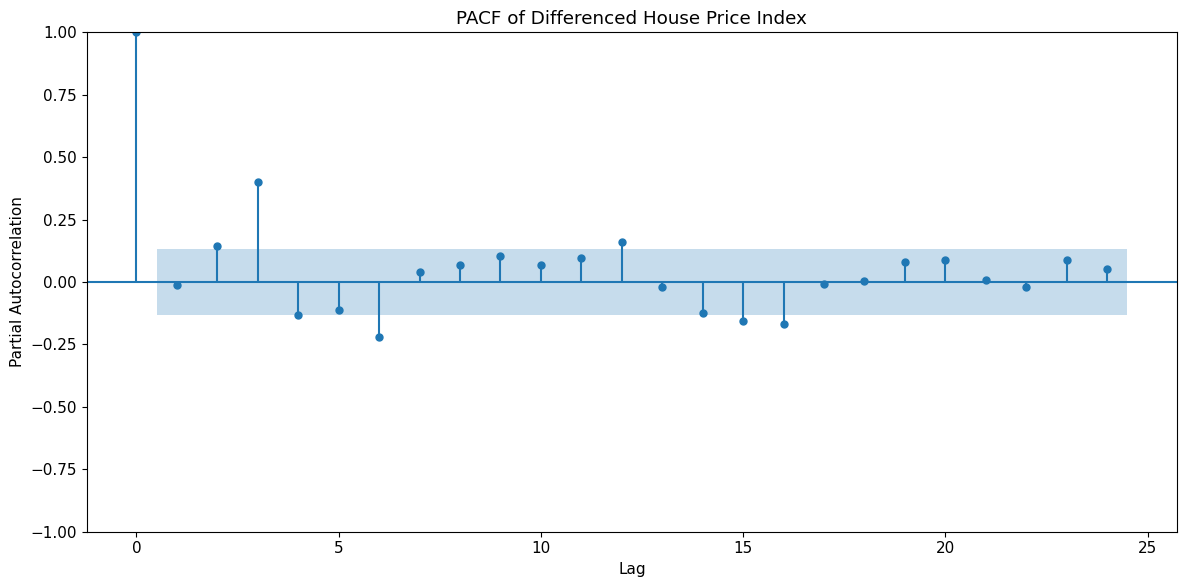

In [103]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["House_Price_Index"], lags=24, method="ywm")
plt.title("PACF of Differenced House Price Index")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced Current Accounts**

<Figure size 1000x400 with 0 Axes>

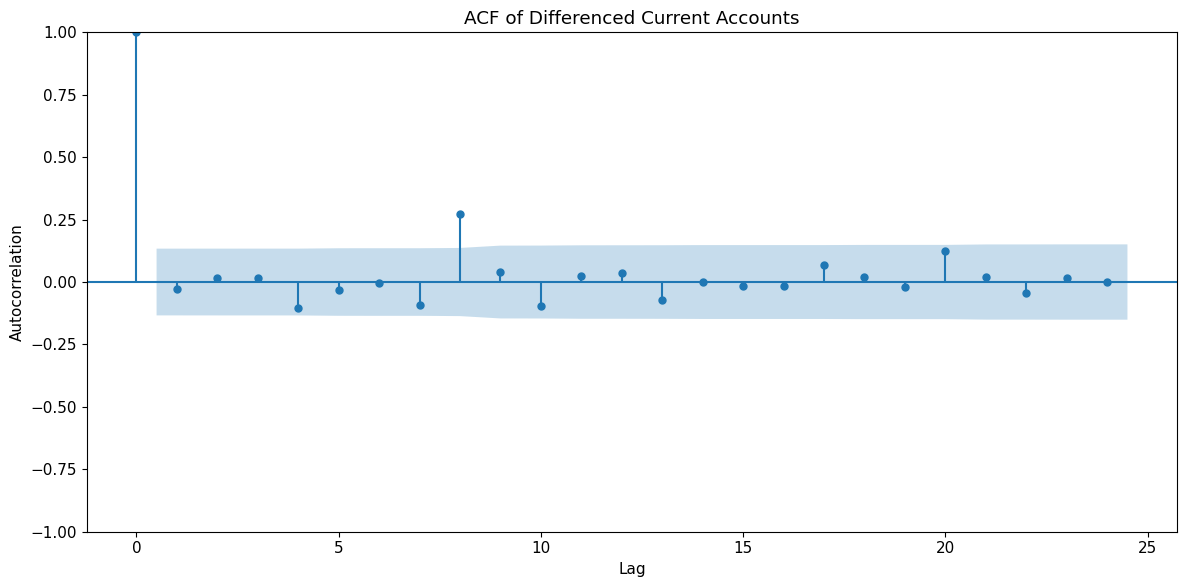

In [98]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["Current_Accounts"], lags=24)
plt.title("ACF of Differenced Current Accounts")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced Current Accounts**

<Figure size 1000x400 with 0 Axes>

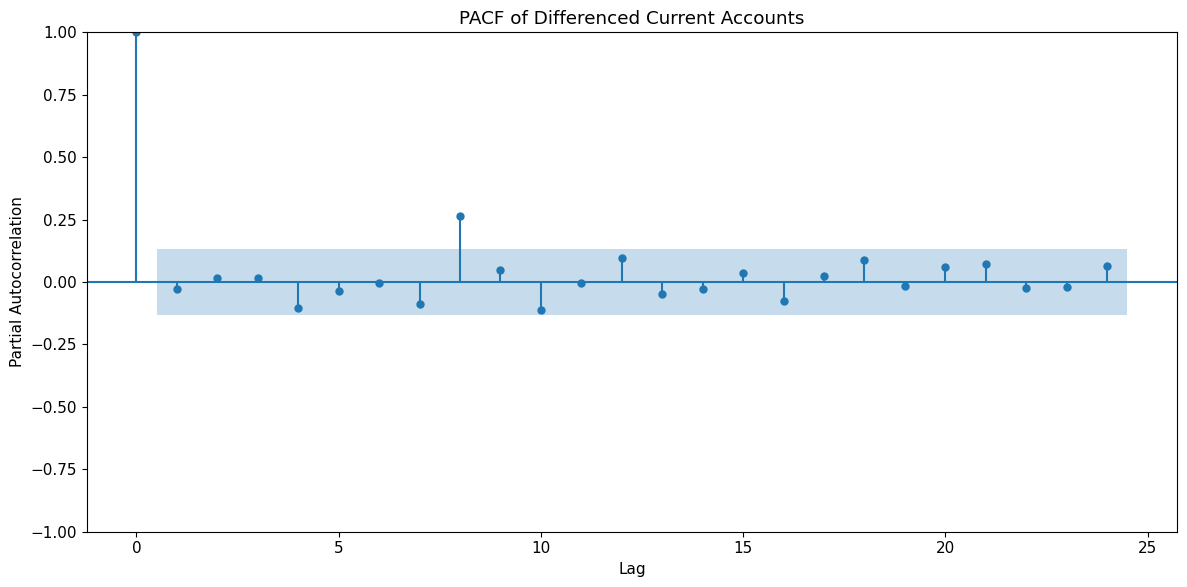

In [104]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["Current_Accounts"], lags=24, method="ywm")
plt.title("PACF of Differenced Current Accounts")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced Savings Accounts**

<Figure size 1000x400 with 0 Axes>

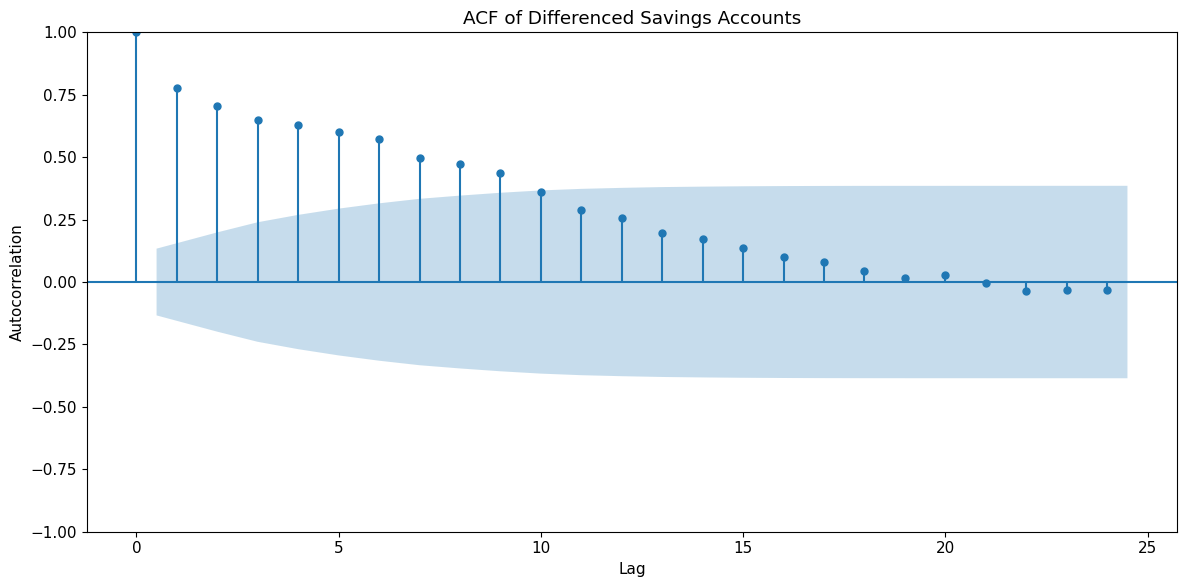

In [99]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["Savings_Accounts"], lags=24)
plt.title("ACF of Differenced Savings Accounts")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced Savings Accounts**

<Figure size 1000x400 with 0 Axes>

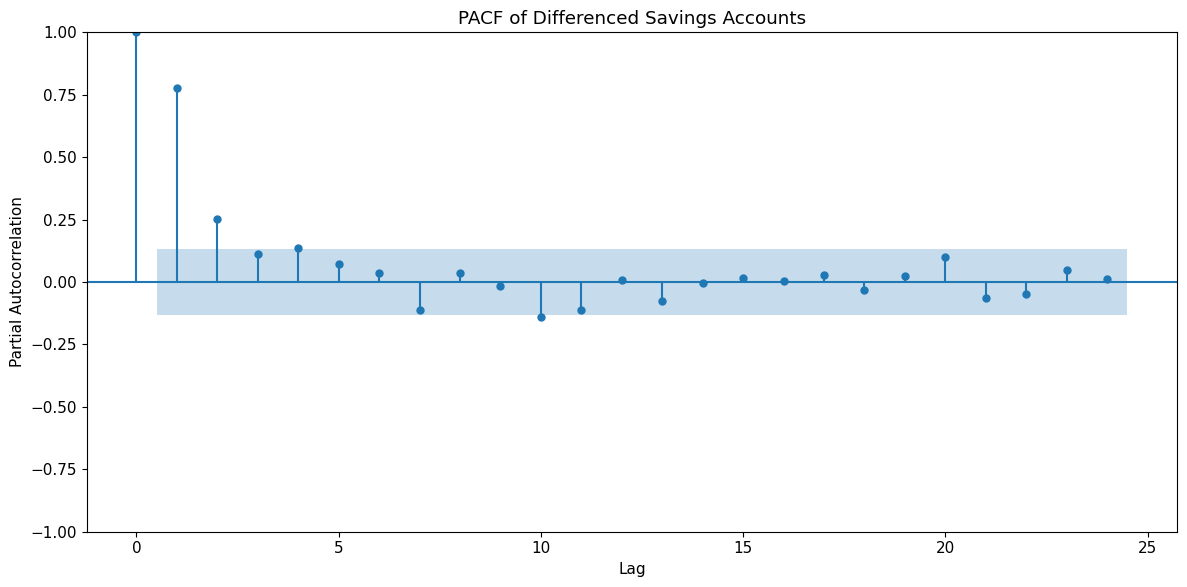

In [105]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["Savings_Accounts"], lags=24, method="ywm")
plt.title("PACF of Differenced Savings Accounts")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**ACF of Differenced Consumer Credit**

<Figure size 1000x400 with 0 Axes>

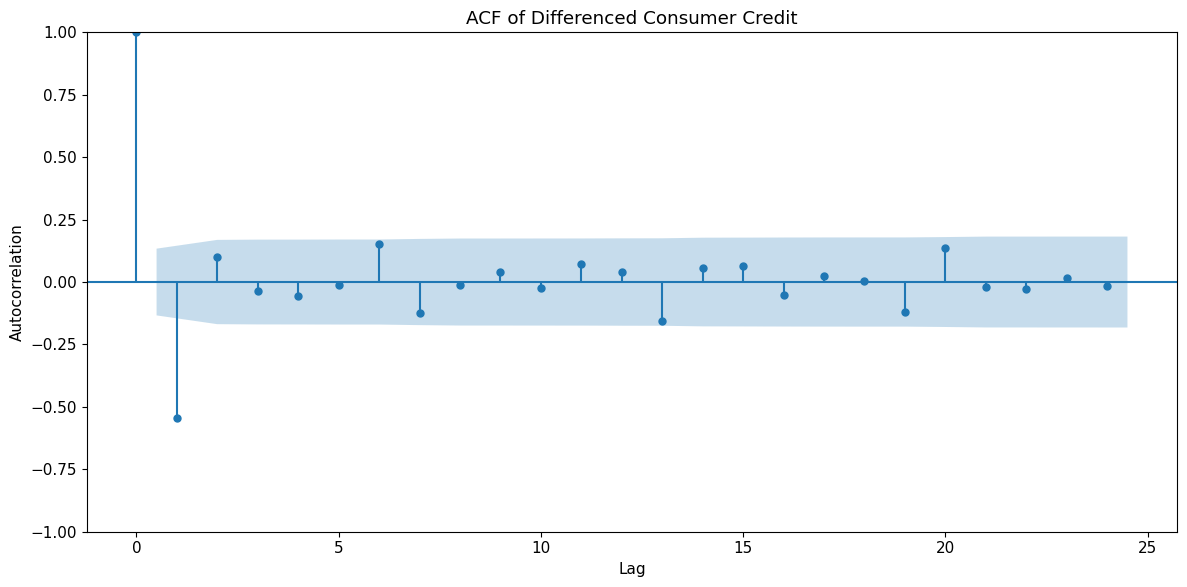

In [100]:
plt.figure(figsize=(10,4))
plot_acf(df_diff["Consumer_Credit"], lags=24)
plt.title("ACF of Differenced Consumer Credit")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

**PACF of Differenced Consumer Credit**

<Figure size 1000x400 with 0 Axes>

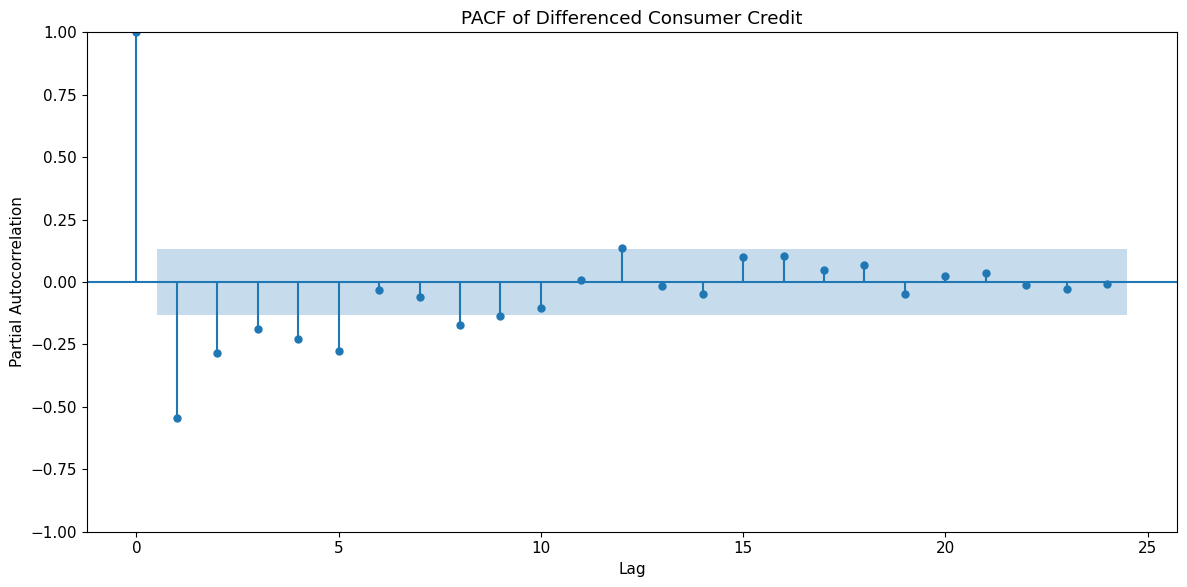

In [106]:
plt.figure(figsize=(10,4))
plot_pacf(df_diff["Consumer_Credit"], lags=24, method="ywm")
plt.title("PACF of Differenced Consumer Credit")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**Seasonal Decomposition Analysis**

**Bank Rate decomposition**

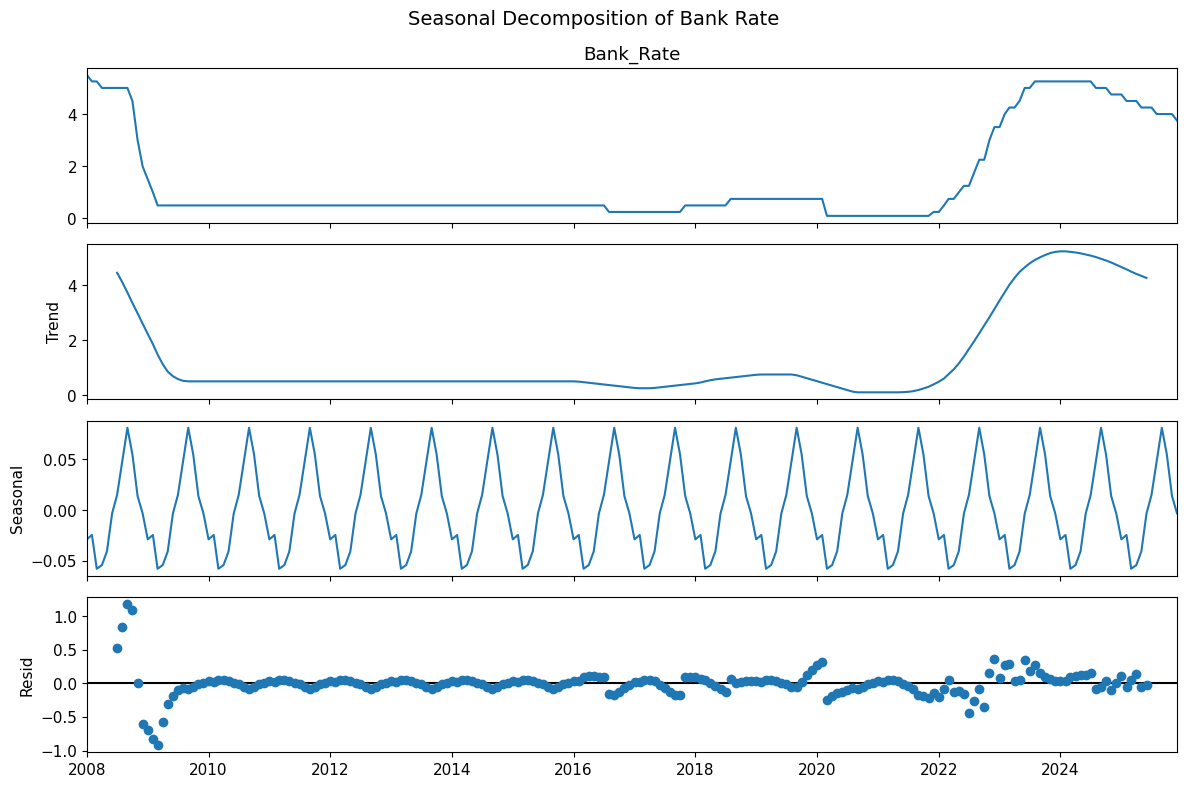

In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(df["Bank_Rate"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Bank Rate", fontsize=14)
plt.tight_layout()
plt.show()

**CPI decomposition**

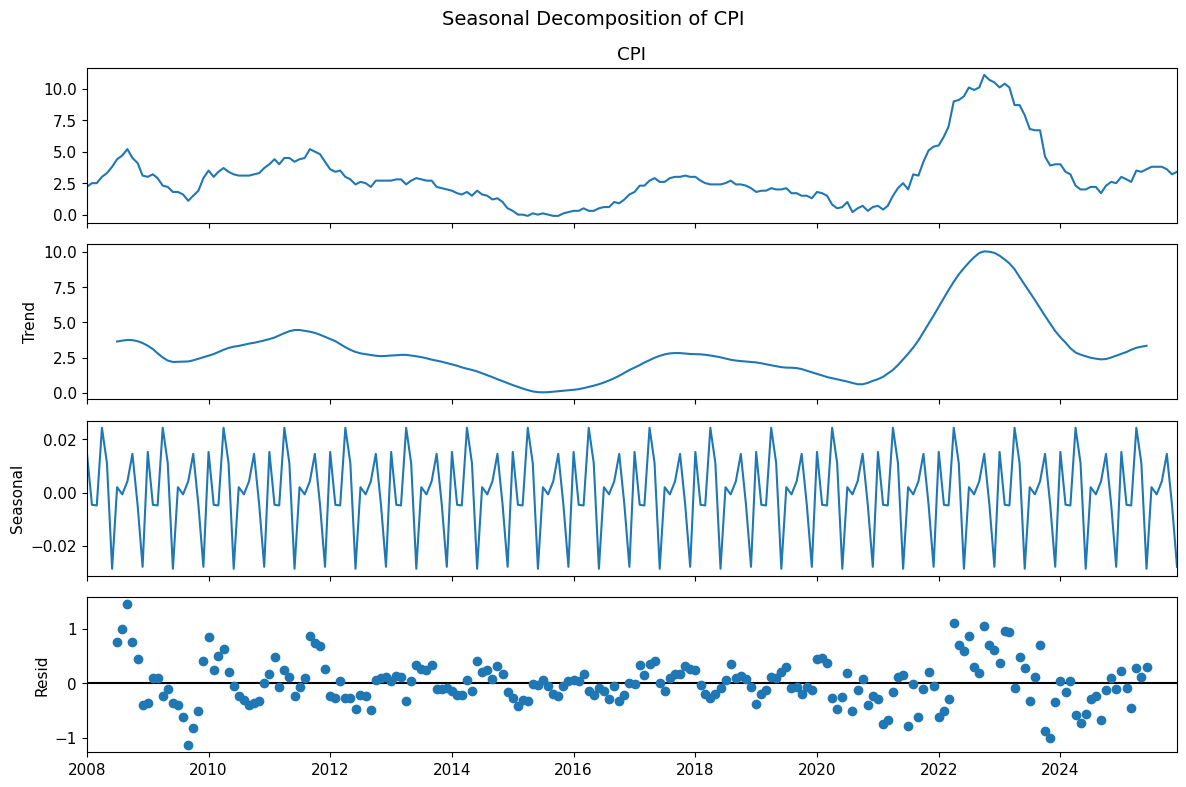

In [108]:
decomp = seasonal_decompose(df["CPI"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of CPI", fontsize=14)
plt.tight_layout()
plt.show()

**Mortgage Approvals decomposition**

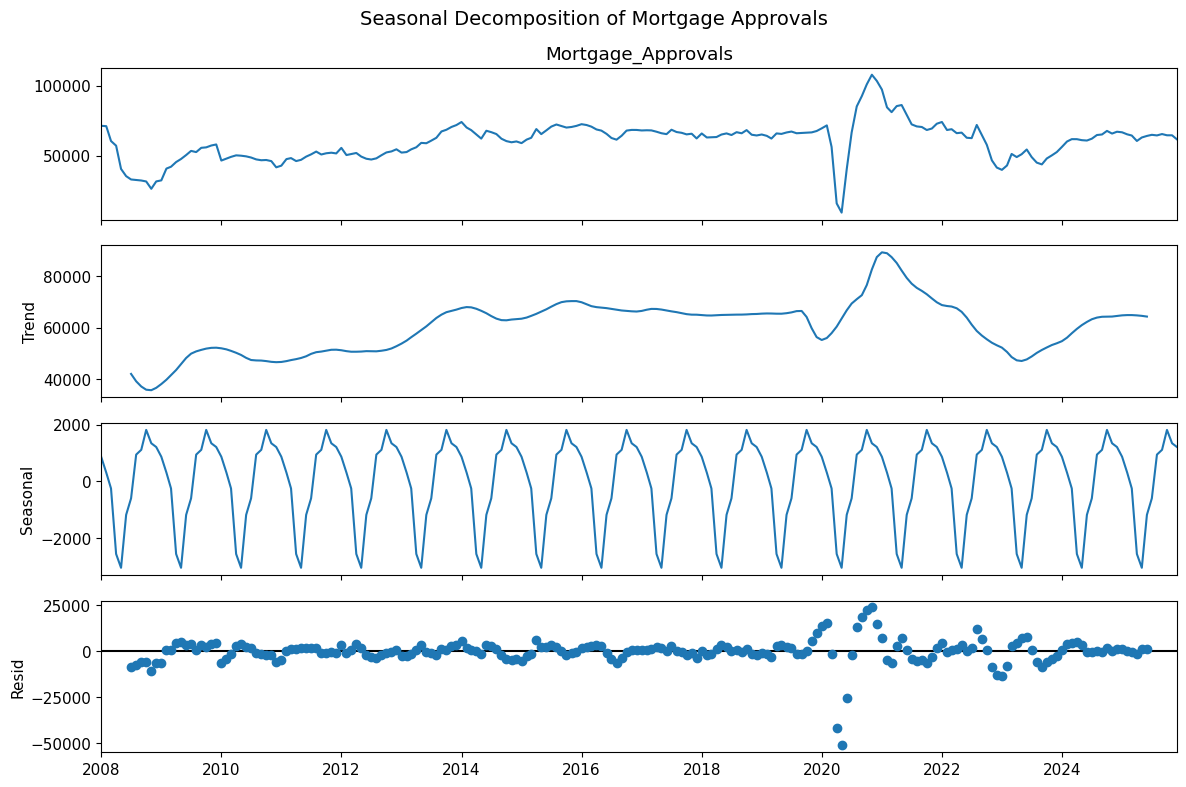

In [109]:
decomp = seasonal_decompose(df["Mortgage_Approvals"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Mortgage Approvals", fontsize=14)
plt.tight_layout()
plt.show()

**Current Accounts decomposition**

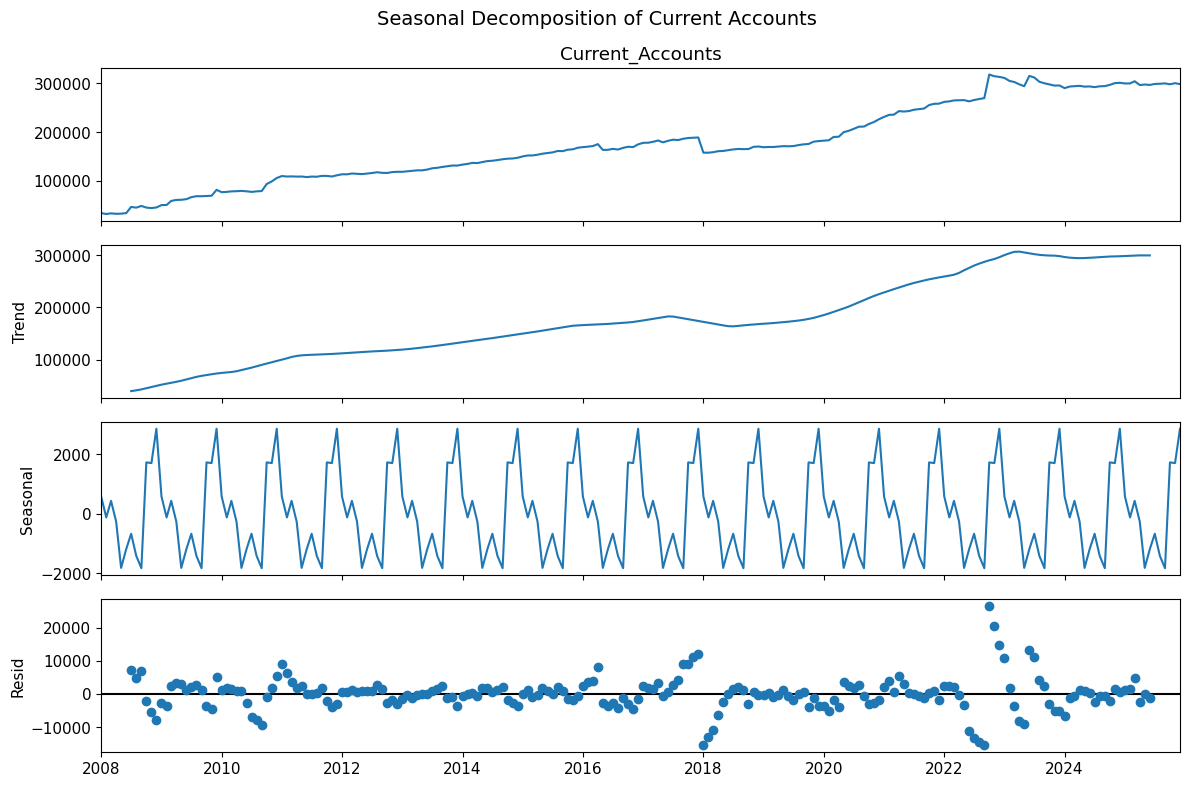

In [110]:
decomp = seasonal_decompose(df["Current_Accounts"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Current Accounts", fontsize=14)
plt.tight_layout()
plt.show()

**Savings Accounts decomposition**

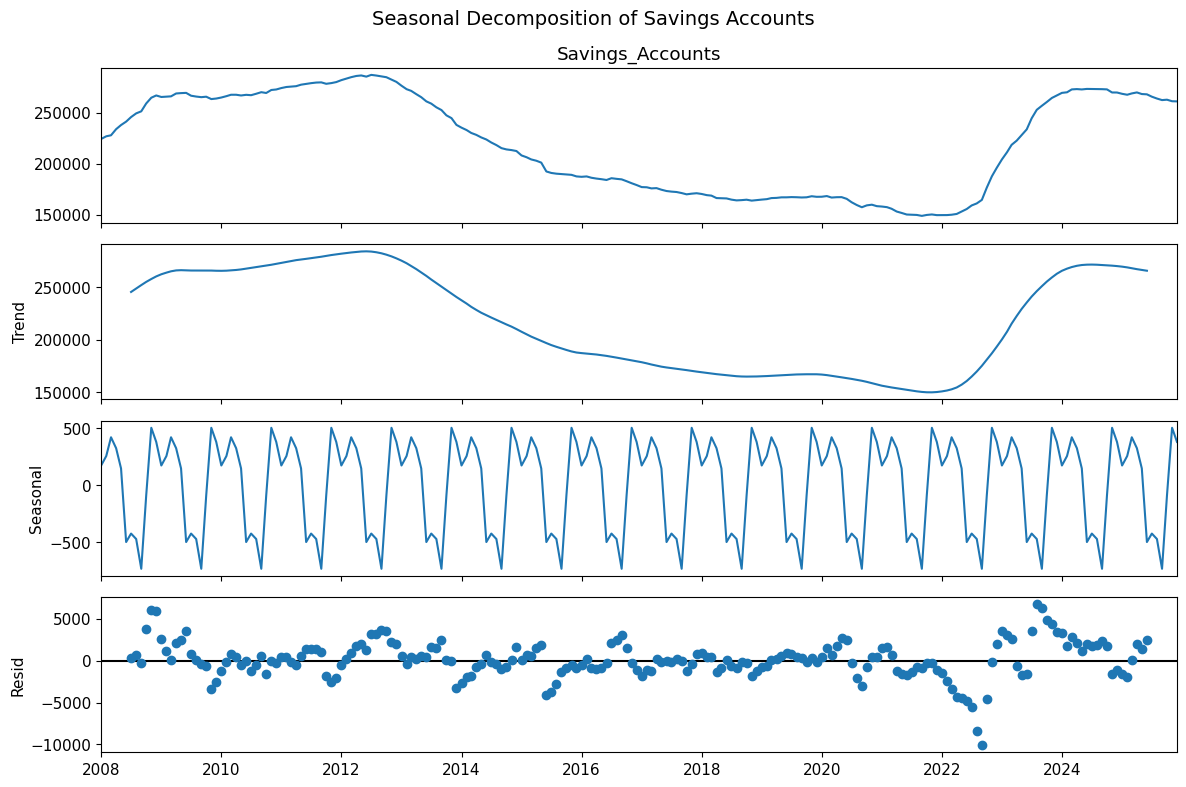

In [111]:
decomp = seasonal_decompose(df["Savings_Accounts"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Savings Accounts", fontsize=14)
plt.tight_layout()
plt.show()

**Consumer Credit decomposition**

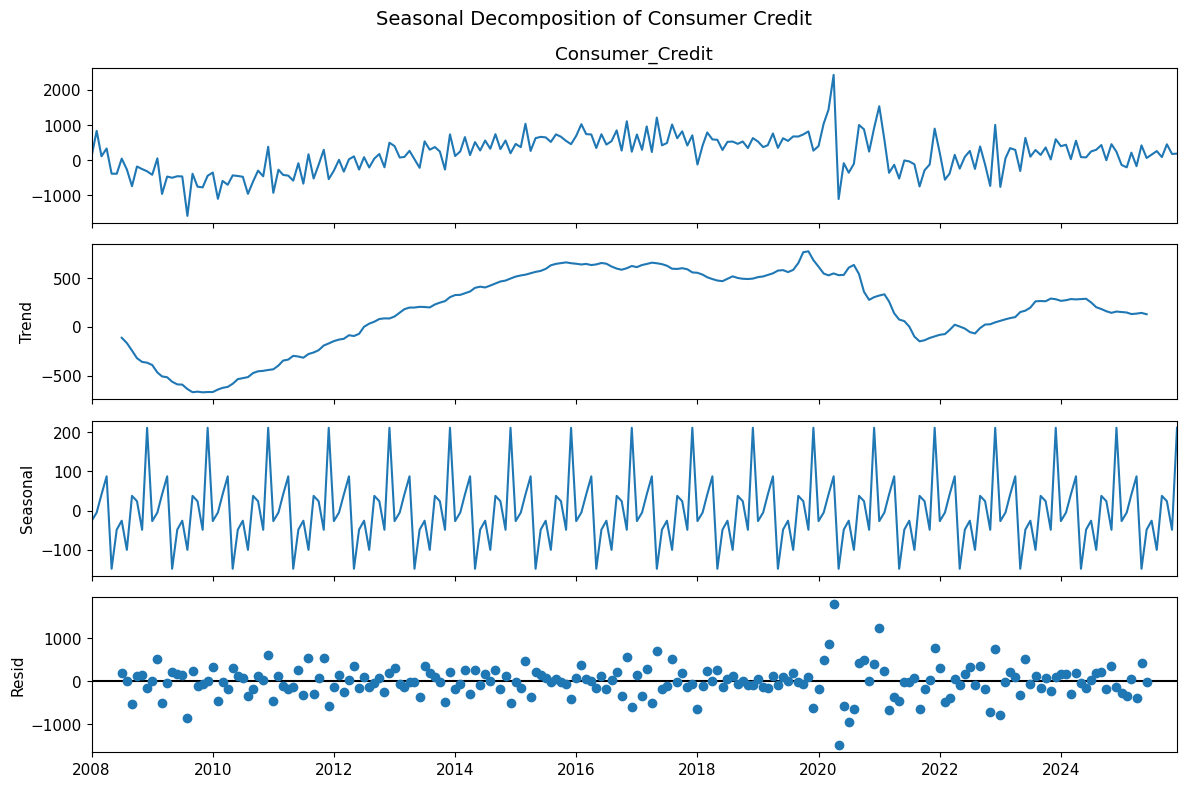

In [112]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(df["Consumer_Credit"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Consumer Credit", fontsize=14)
plt.tight_layout()
plt.show()

**Credit Card Lending decomposition**

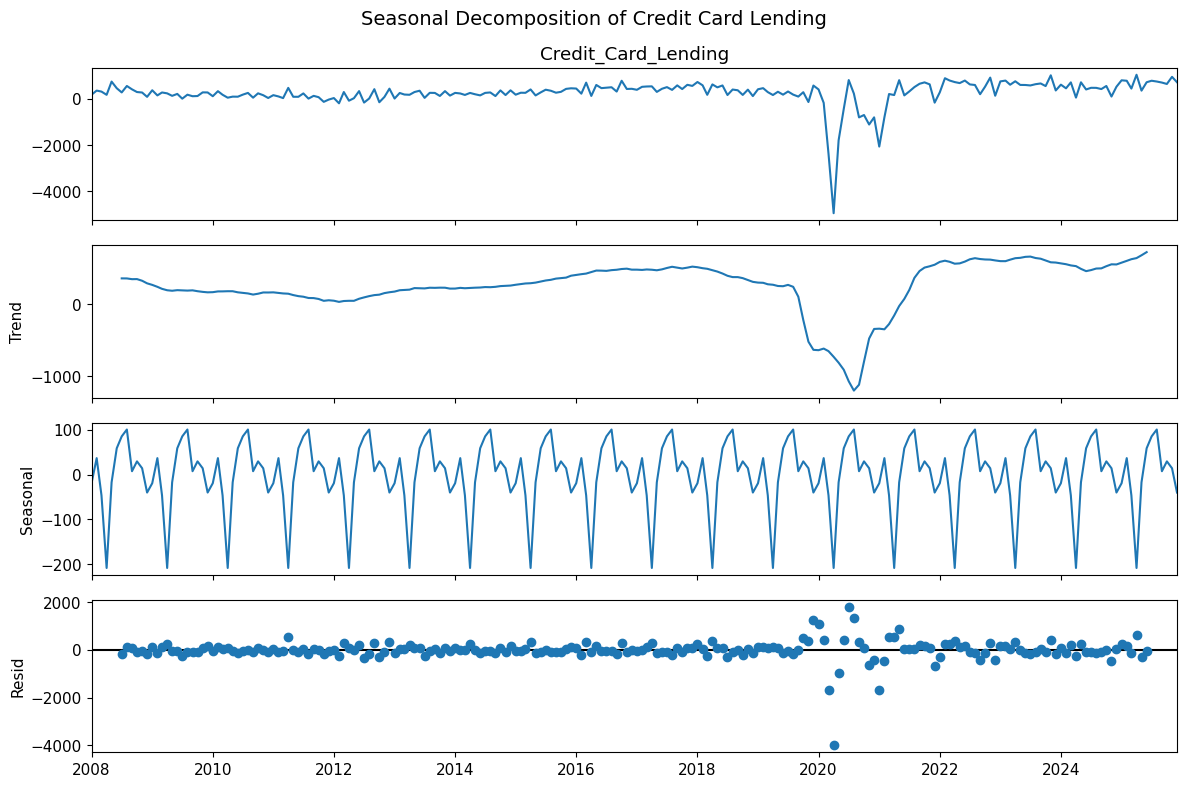

In [113]:
decomp = seasonal_decompose(df["Credit_Card_Lending"].dropna(), model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Credit Card Lending", fontsize=14)
plt.tight_layout()
plt.show()